## Introducción

# Análisis de tasa de cancelación de clientes en banco ABC

En este proyecto se llevará a cabo un análisis de datos relacionados con clientes que han cancelado su servicio en el banco multinacional ABC. El objetivo principal es identificar *insights* relevantes a partir del conjunto de datos que permitan predecir de manera efectiva la deserción de clientes. Utilizando estos datos se desarrollarán modelos de Machine Learning y Deep Learning que permitarán detectar potenciales patrones de deserción de clientes para así implementar estrategias de retención.

El conjunto de datos que será utilizado fue obtenido del repositorio Kaggle y se encuentra disponible en el siguiente enlace: [Bank Customer Churn Dataset](https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data)

----

## Carga y descripción del conjunto de datos

Para realizar el análisis de datos, importamos algunas de las librerías que se requeriran.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
#matplotlib inline

Importamos el conjunto de datos e imprimimos las primeras instancias.

In [2]:
df_raw = pd.read_csv('C:/Users/Adrej/OneDrive/Escritorio/Proyectos/BankCustomerChurnPrediction/BankCustomerChurnPrediction.csv')
df_raw.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Como en la mayoría de los conjuntos de datos, este dataset está compuesto por variables numéricas y categóricas. A continuación, se describen brevemente dichas variables:

**Variables numéricas:**
- `credit_score`: Puntaje crediticio basado en el análisis del historial financiero del cliente. Representa su solvencia, y usualmente varía en un rango de 300 a 850.
- `age`: Edad del cliente.
- `tenure`: Años de antigüedad del cliente como usuario del banco.
- `balance`: Saldo actual en la cuenta del cliente.
- `products_number`: Número de productos o servicios financieros contratados (por ejemplo, tarjeta de crédito, débito, préstamos, etc.).
- `estimated_salary`: Ingreso estimado del cliente, ya sea reportado o inferido, generalmente expresado en términos anuales.

**Variables categóricas**:
- `country`: País de residencia del cliente.
- `gender`: Género del cliente.
- `credit_card`: Variable binaria que indica si el cliente posee una tarjeta de crédito emitida por el banco ABC.
- `active_member`: Variable binaria que señala si el cliente ha estado activo recientemente (por ejemplo, mediante transacciones u operaciones bancarias).

**Variable objetivo**:
- `churn`: Variable binaria que indica si el cliente ha cancelado su servicio con el banco (0: No, 1: Sí).

Adicionalmente, el conjunto de datos contiene la variable `customer_id`, que corresponde únicamente al identificador único del cliente. Dado que no aporta información útil para el análisis predictivo, se excluirá del conjunto de características en la etapa del preprocesamiento.

A continuación, se presentan los tipos de datos de cada una de las variables del conjunto.

In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


Se observa que el conjunto de datos contiene 10,000 instancias y que no presenta valores nulos en ninguna de sus variables. A continuación, se muestran las distribuciones generales de las variables, así como un resumen estadístico de sus características numéricas.

In [4]:
df_raw.describe(include = 'all')

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.569094e+07,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


Observamos que la variable de países (`contry`) contiene sólo 3 valores distintos, los cuales son:

In [5]:
df_raw['country'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

Por último, revisaremos la variable objetivo `churn` lo cual nos permitirá conocer la distribución de las instancias del conjunto de datos.

In [6]:
df_raw['churn'].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

Como se puede observar, la variable objetivo presenta un desequilibrio en la distribución de clases, por lo cual es importante tener precaución al momento de entrenar modelos, ya que podrían inclinarse a favorecer la clase mayoritaria, lo que resultaría en un sobreajuste y un rendimiento deficiente en la detección de la clase minoritaria.

----

## Preprocesamiento de datos

Dado que el conjunto de datos no cuenta con valores nulos, que no es necesario realizar un proceso de limpieza en el preprocesamiento. Como se mencionó, es necesario eliminar la columna `customer_id` dado que no aporta información relevante. Además, se observó que la variable `gender` está codificada como una cadena de texto (`string`). Para facilitar el uso de esta variable se convertirá a variable numérica. Para ello, se asignarán los siguientes valores:
* `Male`: 0
* `Female`: 1

In [7]:
df_raw = df_raw.drop(columns = ['customer_id'])

In [8]:
df_raw['gender'] = df_raw['gender'].map({'Male': 0, 'Female': 1})

----

## Análisis exploratorio de datos

Se analizarán las distribuciones de las variables para cada una de las dos clases de la variable objetivo: clientes que han abandonado el servicio y clientes que mantenienen. Este análisis permitirá identificar diferencias en los patrones de comportamiento entre ambos grupos, lo cual es útil para la detección de *insights* y así construir modelos predictivos más precisos.

### Análisis de variables continuas

In [9]:
numerical_vars = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']

#### Gráfico de violín

Inicialmente, se realizará un análisis de distribuciones para las distintas variables numéricas.

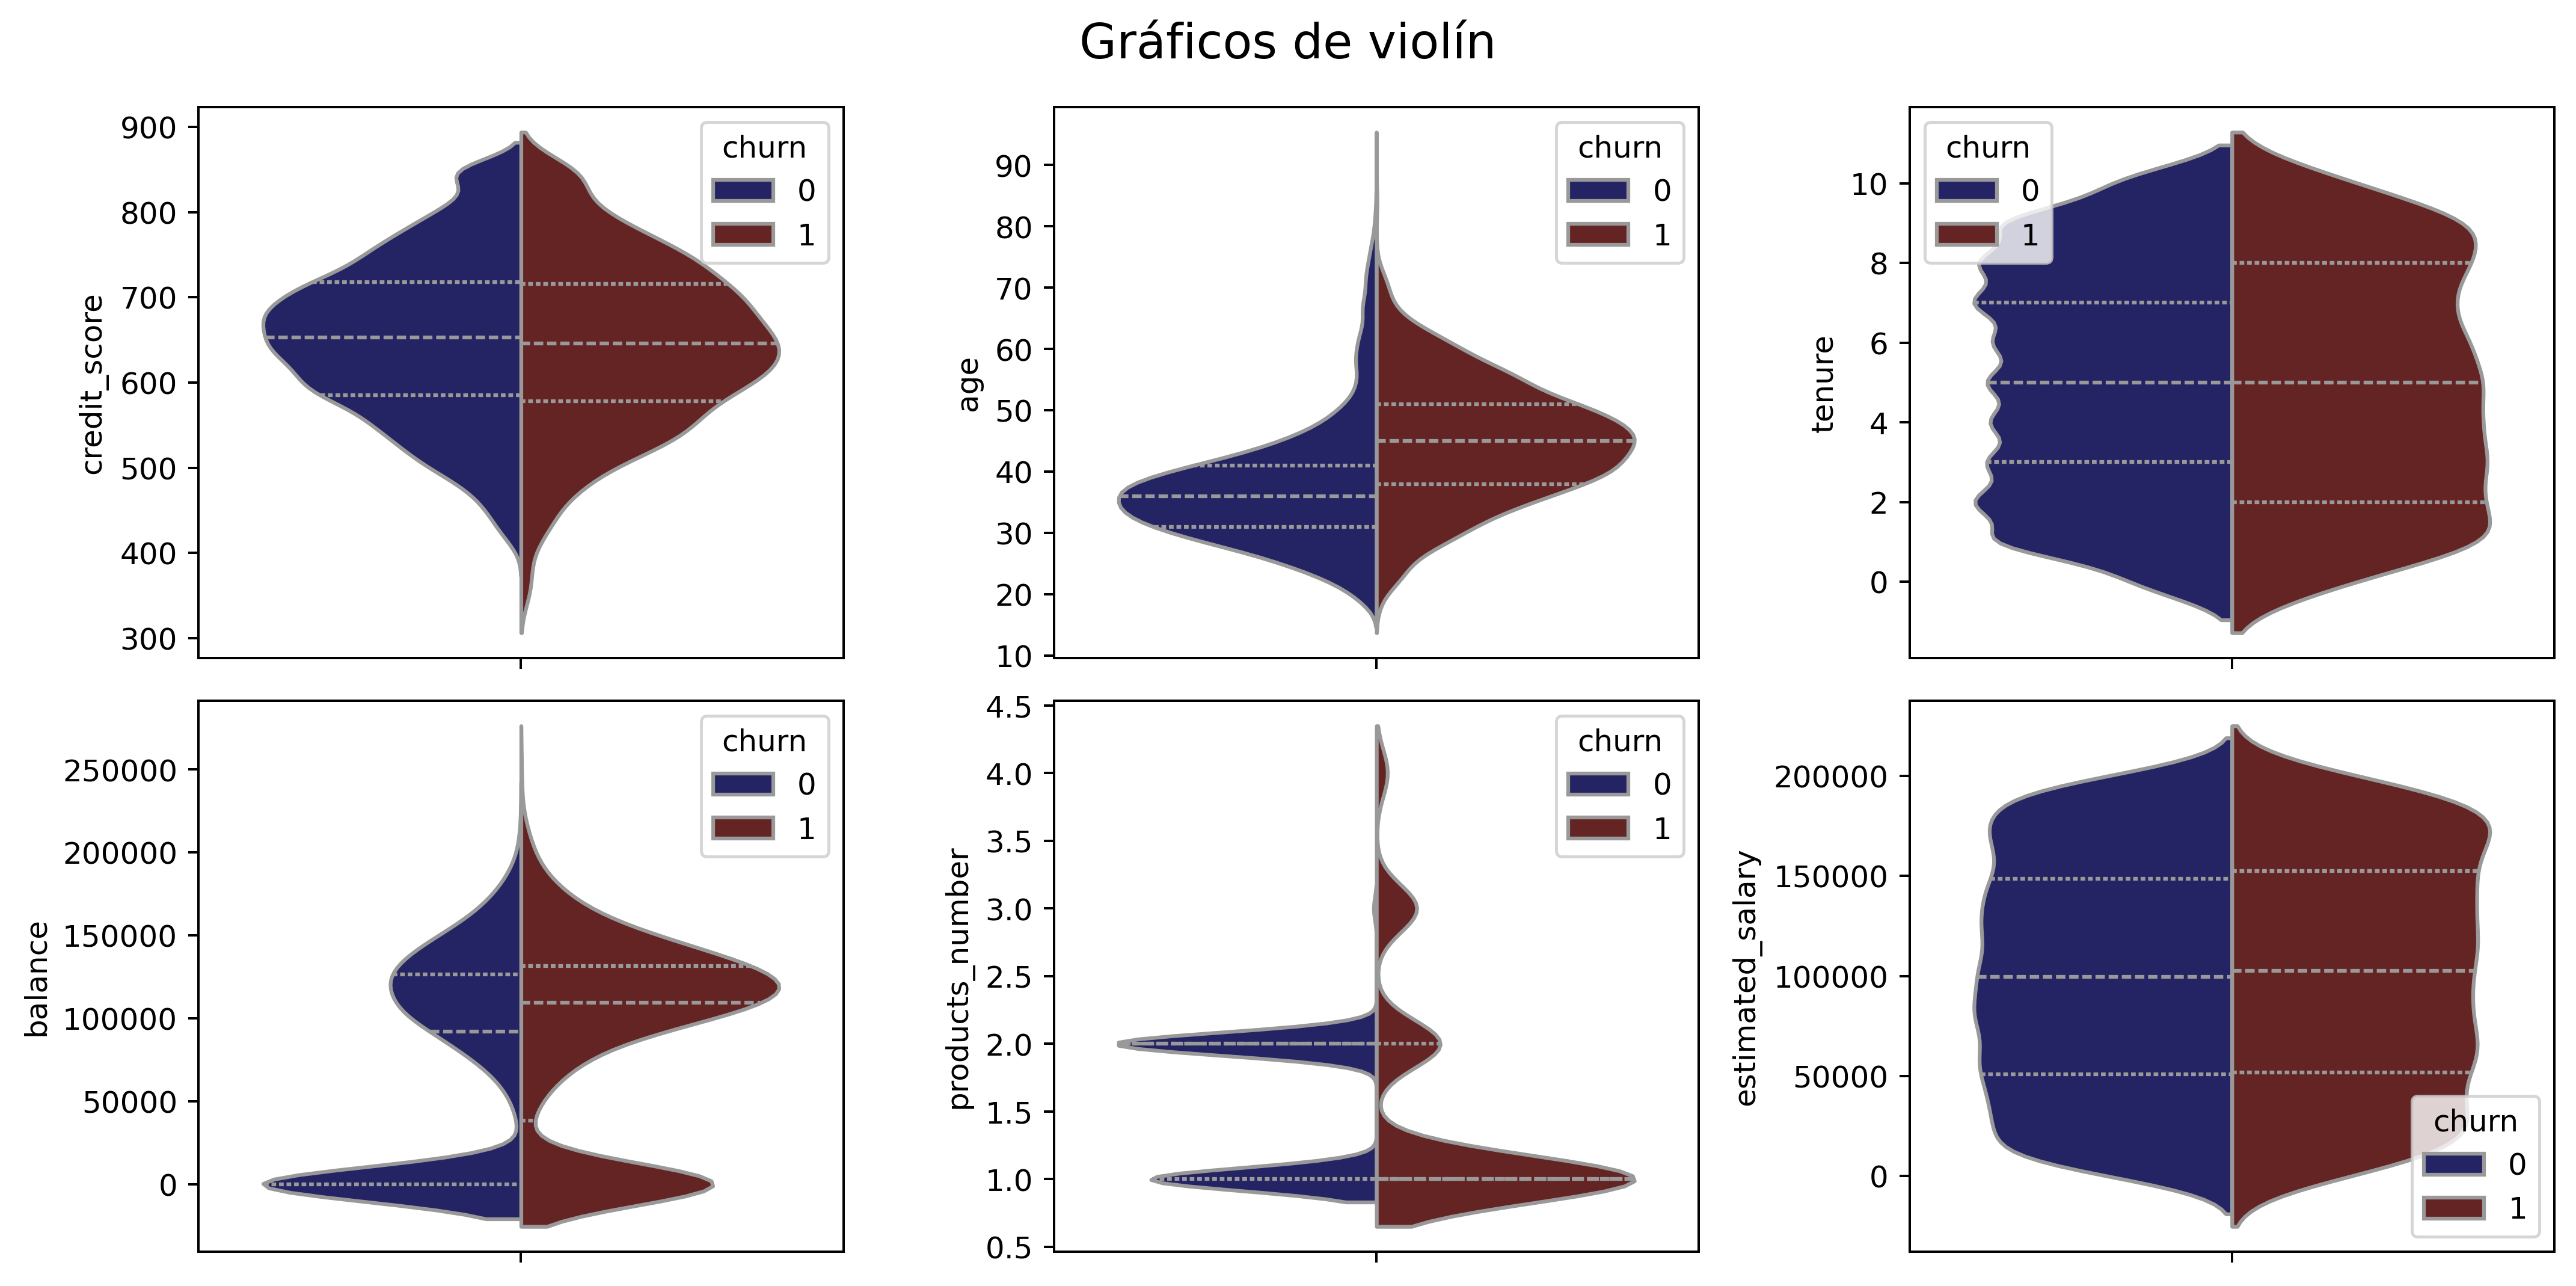

In [10]:
churn_colors = ['#191970', '#701919']
    
fig, axs = plt.subplots(nrows = 2, ncols = 3, dpi = 360, figsize = (12,6))
fig.suptitle('Gráficos de violín', fontsize = 16)
for i, var in enumerate(numerical_vars):
    row, col = divmod(i,3)
    sns.violinplot(data=df_raw, y=var, hue = 'churn',
                   palette=churn_colors, split=True, inner='quart', ax = axs[row][col], fill = True, linecolor = '#999999')
    axs[row][col].set_ylabel(var)
plt.tight_layout()
plt.show()


A partir de los gráficos de violín generados, es posible extraer algunas observaciones relevantes sobre el comportamiento de los clientes que abandonan o permanecen en la institución financiera. A continuación, se presentan los principales hallazgos junto con preguntas que permitirán realizar un análisis estadístico posterior:

**Similitud en distribuciones de algunas variables**: A simple vista, las distribuciones de puntaje crediticio (`credit_score`), antigüedad en el banco (`tenure`) y salario estimado (`estimated_salary)` parecen ser similares entre los clientes que abandonaron y los que permanecen en la institución.

- ¿Es esto cierto desde el punto de vista estadístico?
- ¿Qué variables numéricas presentan distribuciones similares entre ambos grupos?

**Edad como posible factor determinante**: Se observa que la mayoría de los clientes que abandonan el banco tienen edades comprendidas entre los 37 y 52 años, con una media cercana a los 44 años.

- ¿Estadísticamente, los clientes que abandonan tienden a ser mayores que los que permanecen?
- ¿Existen otras variables cuya media difiera significativamente entre ambos grupos?

**Relación entre saldo y abandono**: Se observa que la proporción de clientes con un saldo igual a $0 en su cuenta tienen mayor tendencia a permanecer en el banco, mientras que aquellos con saldos superiores a la media muestran una mayor tendencia a abandonarlo.

- ¿Cómo se distribuye el saldo entre los clientes que se quedan y los que se van?

**Número de productos contratados**: En la distribución de clientes que han abandonado el banco, se observa un número considerable de casos con tres o cuatro productos contratados, patrón menos evidente entre los clientes que no han abandonado. Además, la mayoría de los clientes que no han abandonado tienden a tener dos productos, mientras que entre los que sí han abandonado, predomina tener solo un producto.
- ¿Existe evidencia estadística de que los clientes con un solo producto tienen mayor probabilidad de abandonar el banco?
- ¿Cómo se asigna el número de productos a cada cliente?
- ¿Podría tratarse de una estrategia de retención el ofrecer más productos a clientes en riesgo de abandono?
- ¿Existe una relación entre no adquirir más productos y la decisión de abandonar?

En las siguientes secciones se abordarán estas preguntas mediante análisis estadísticos apropiados, con el fin de darle respuesta a las preguntas planteadas a partir de la inspección visual.

#### Similitud en distribuciones de variables

Si bien el gráfico de violín sirve para identificar variaciones en las distribuciones de los datos, el gráfico de la función de distribución acumulada, o *CDF*, permite una comparación entre las distribuciones de las dos clases de manera más clara. A continuación obtenemos los gráficos CDF para las distintas variables.

In [11]:
df_NoChurn  = df_raw[df_raw['churn']==0]
df_Churn  = df_raw[df_raw['churn']==1]

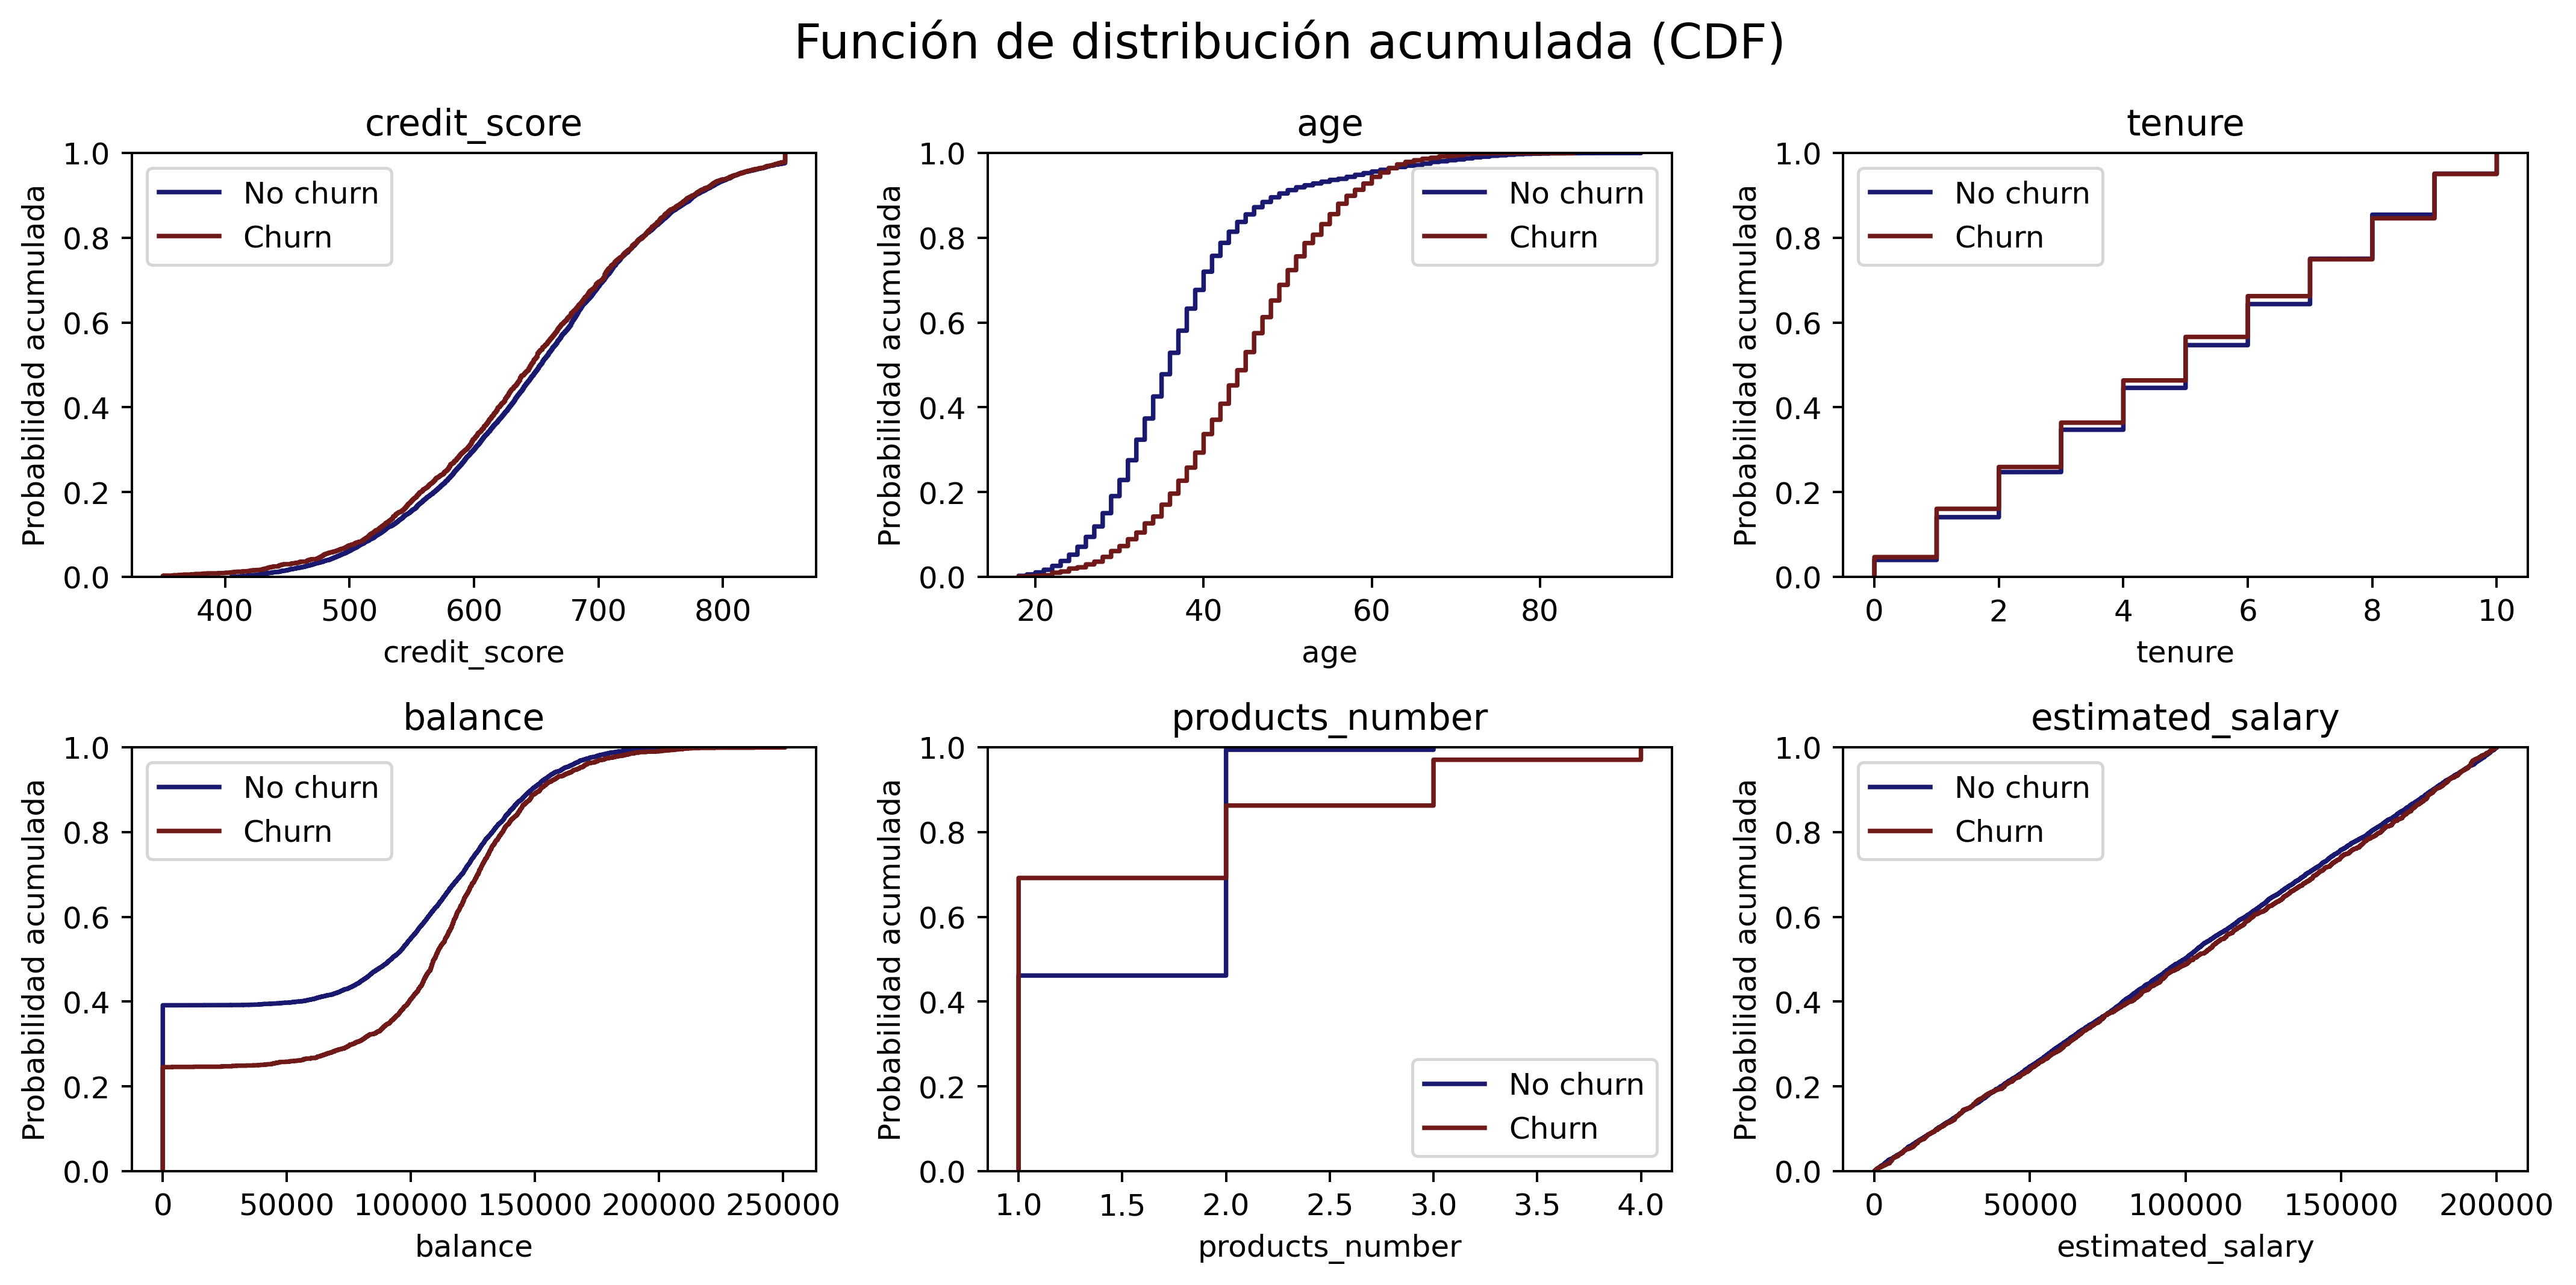

In [12]:
fig, axs = plt.subplots(nrows = 2, ncols = 3, figsize=(12,6), dpi = 360)
fig.suptitle('Función de distribución acumulada (CDF)', fontsize = 16)
for i,var in enumerate(numerical_vars):
    row, col = divmod(i,3)
    axs[row,col].set_title(var)
    axs[row,col].ecdf(df_NoChurn[var], color = churn_colors[0], label = 'No churn')
    axs[row,col].ecdf(df_Churn[var], color = churn_colors[1], label = 'Churn')
    axs[row,col].legend()
    axs[row,col].set_ylabel('Probabilidad acumulada')
    axs[row,col].set_xlabel(var)
plt.tight_layout()
plt.show()

A partir de estas gráficas se puede comparar las distribuciones de ambos grupo desde otro enfoque. Se observa que la edad media de personas que abandonan la institución financiera es mayor que la edad media de las que permanecen. De igual forma, se observa que alrededor del 40\% de todas las personas que permanecen en el banco tienen $\$0$ en su cuenta, mientras que el porcentaje que abandona con $\$0$ de saldo es solo del 25\%. Por otra parte, se aprecia que el 65\% de personas que abandonan la institución cuentan con un solo producto y que son estas las únicas que cuentan con tres y cuatro productos, viendose la cantidad de productos de las personas que permanecen a lo más tres.

#### Relación entre saldo y abandono

En las gráficas de violín y de CDF se observó que las distribuciones de `balance` de ambos grupos son relativamente parecidas. Se analizará a profundidad esta distribución para ambas clases. Se comparará el histograma de cada clase para esta variable.

In [13]:
min_balance = df_raw['balance'].min()
max_balance = df_raw['balance'].max()

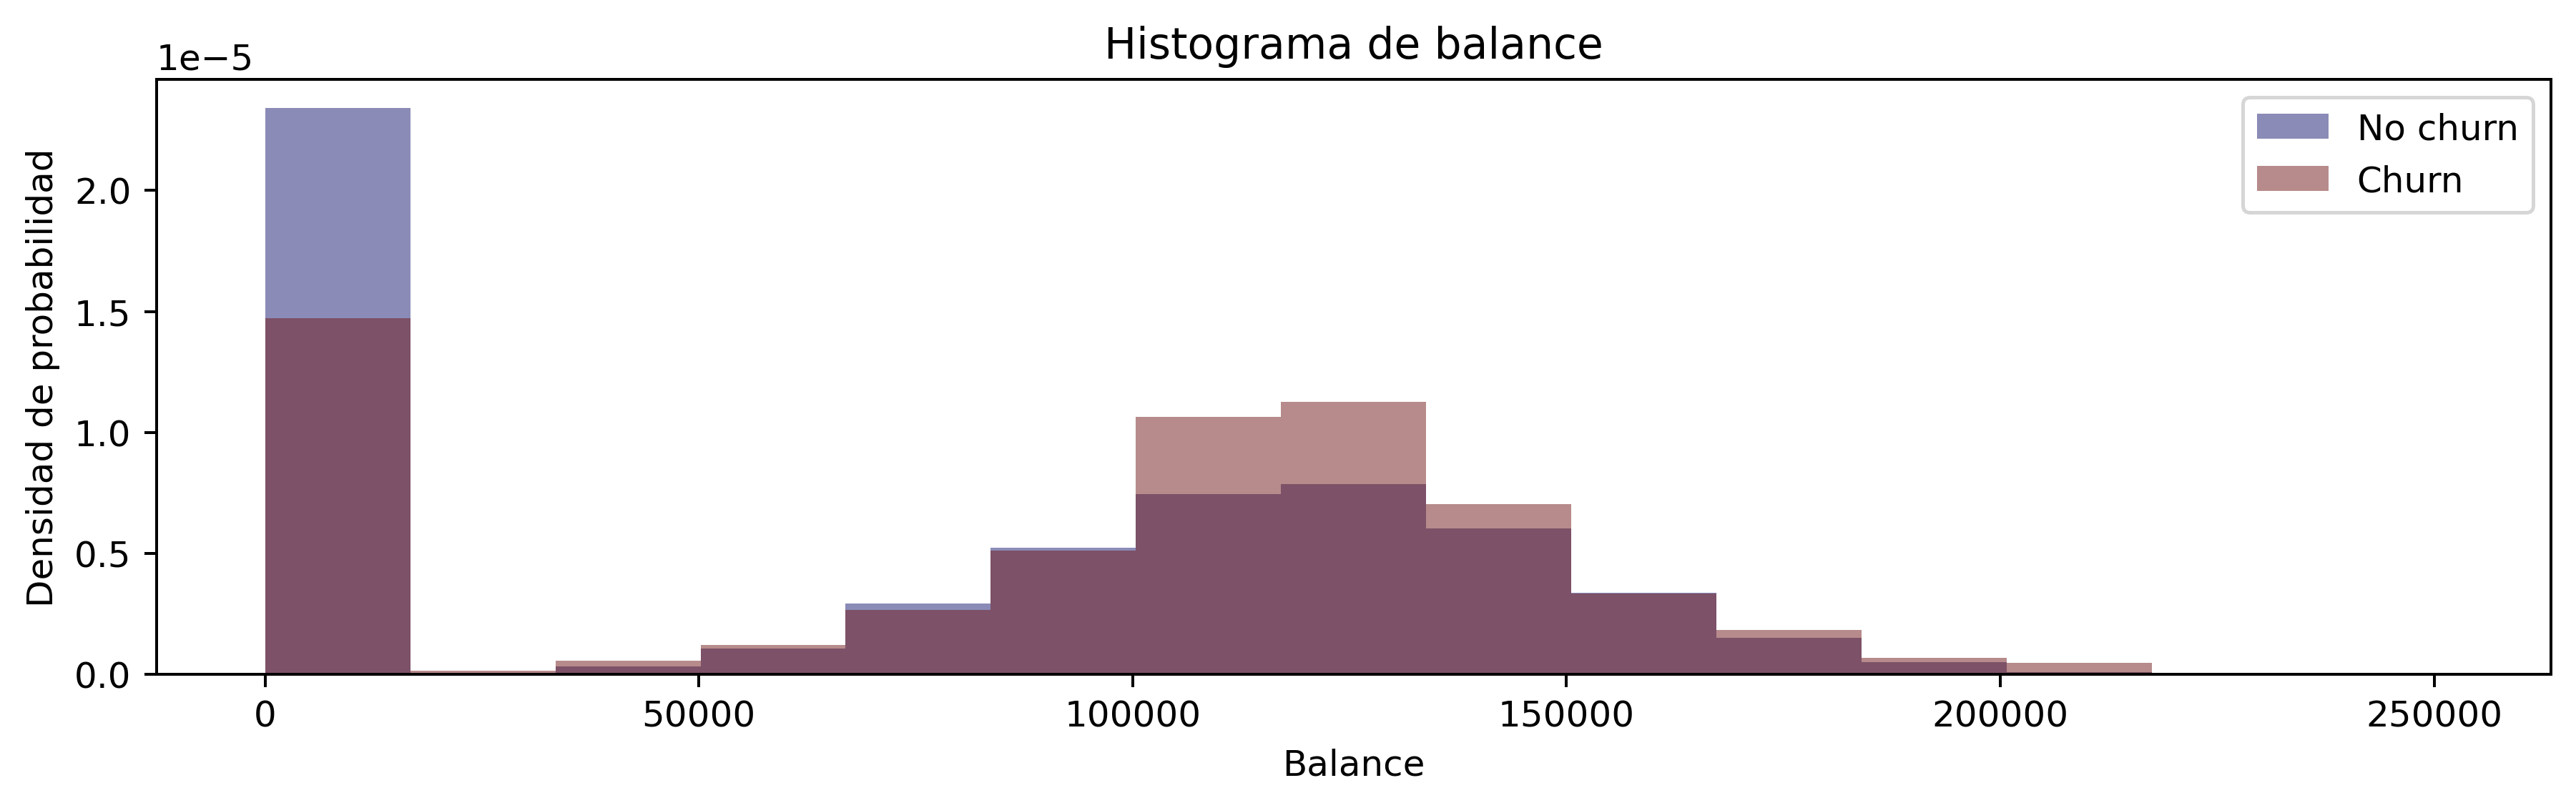

In [14]:
plt.figure(dpi = 360, figsize = (12,3))
plt.hist(df_NoChurn['balance'], bins = 15, color = churn_colors[0], range = [min_balance, max_balance], label = 'No churn', density = True, alpha =0.5)
plt.hist(df_Churn['balance'], bins = 15,   color = churn_colors[1], range = [min_balance, max_balance], label = 'Churn', density = True, alpha = 0.5)
plt.legend()
plt.xlabel("Balance")
plt.ylabel("Densidad de probabilidad")
plt.title('Histograma de balance')
plt.show()

Se puede observar que la distribución central de datos es parecida para ambas clases, con la unica diferencia de que existe una gran cantidad de clientes con un saldo de $\$0$ en sus cuentas, siendo mayor el porcentaje de clientes que permanecen con respecto al porcentaje que abandona el banco. Para observar similitudes, se graficará el conjunto de datos para aquellos clientes que tengan un saldo mayor a $0.

In [15]:
NonZeroBalance_NoChurn = df_NoChurn[df_NoChurn['balance'] > 0]['balance']
NonZeroBalance_Churn = df_Churn[df_Churn['balance'] > 0]['balance']

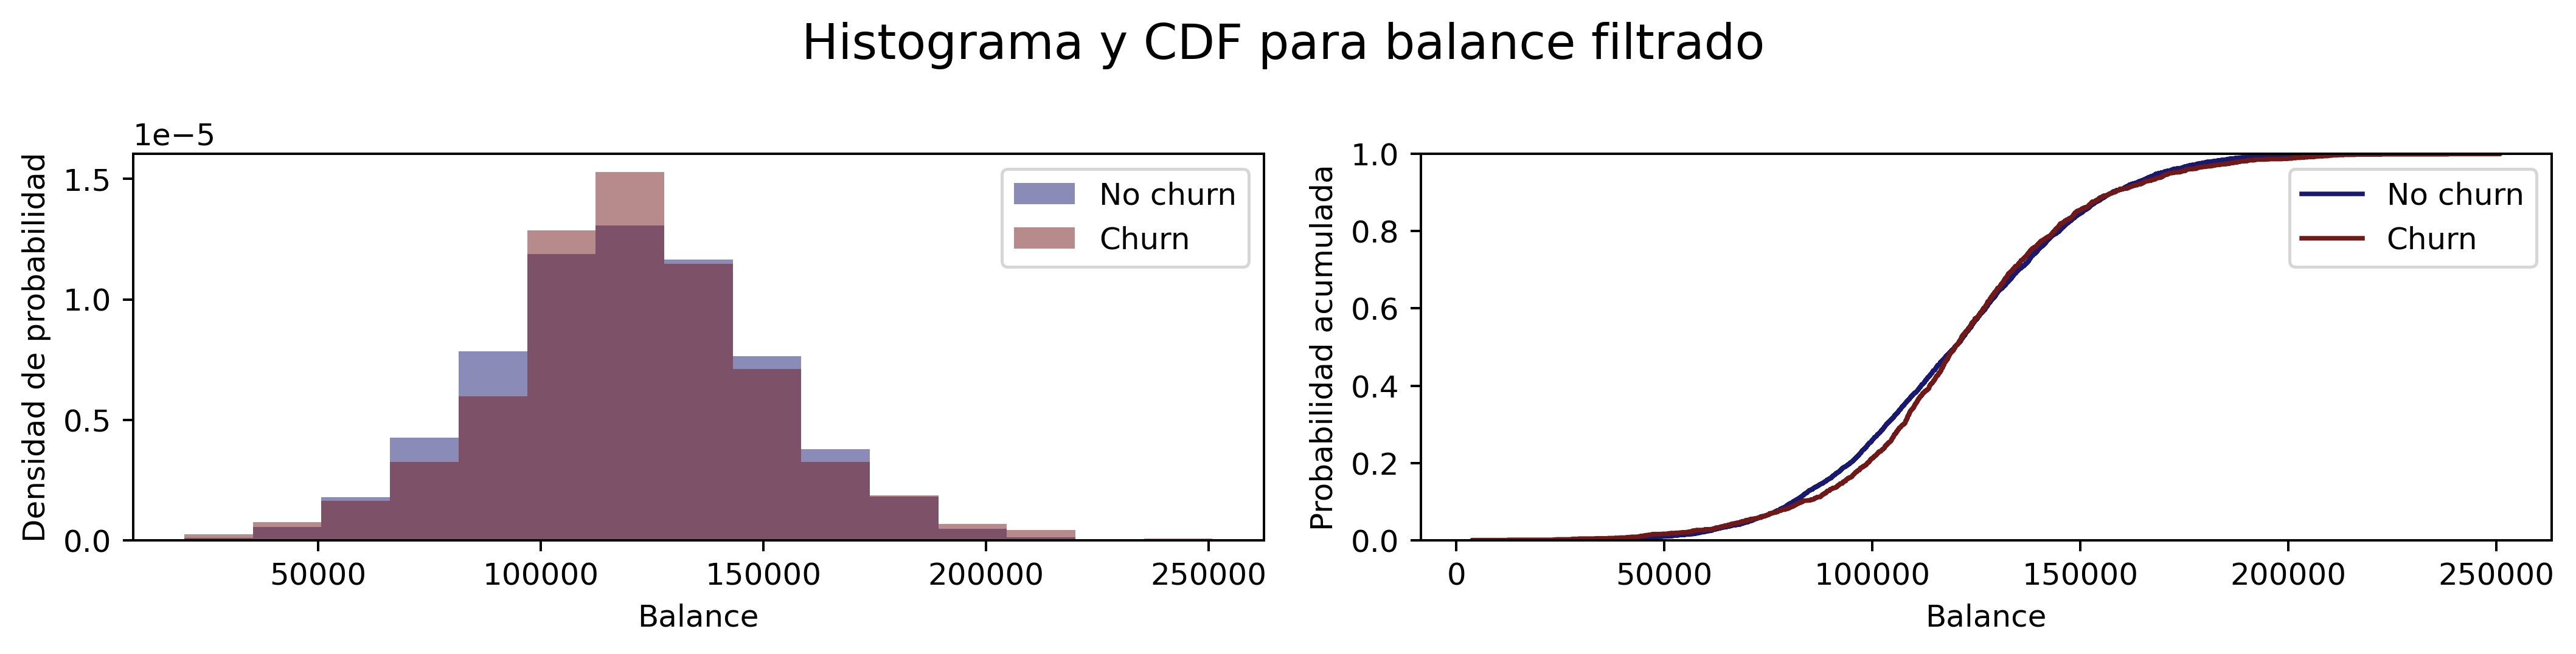

In [16]:
fig, axs = plt.subplots(nrows=1, ncols=2, dpi=360, figsize=(12, 3))
fig.suptitle('Histograma y CDF para balance filtrado', fontsize = 16)
axs[0].hist(NonZeroBalance_NoChurn, bins=15, color=churn_colors[0], range=[20000, max_balance], label="No churn",  density = True, alpha = 0.5)
axs[0].hist(NonZeroBalance_Churn, bins=15, color=churn_colors[1], range=[20000, max_balance], label="Churn",  density = True, alpha = 0.5)
axs[0].set_xlabel("Balance")
axs[0].set_ylabel("Densidad de probabilidad")
axs[0].legend()
sns.ecdfplot(NonZeroBalance_NoChurn, ax=axs[1], color=churn_colors[0], label="No churn")
sns.ecdfplot(NonZeroBalance_Churn, ax=axs[1], color=churn_colors[1], label="Churn")
axs[1].set_xlabel("Balance")
axs[1].set_ylabel("Probabilidad acumulada")
axs[1].legend()
plt.tight_layout()
plt.show()


Las gráficas del histograma y de la función de distribución acumulada para la variable `balance` muestran que las distribuciones son similares entre los clientes que abandonan y los que permanecen en el banco. Esto sugiere que, entre clientes que tienen un saldo mayor a $\$0$, no hay diferencias significativas en el comportamiento financiero que permitan distinguir a los clientes según su decisión de permanecer o abandonar la institución. Con esta observación, se plantea lo siguiente:
- ¿La media de clientes que poseen un saldo mayor a $\$0$ es distinta entre clientes que abandonan o permanecen en la institución?
- ¿Es posible extraer información relevante con la concentración de clientes con un saldo de $\$0$?

#### Número de productos por clase

En las gráficas anteriores, se observó que solo los clientes que habían abandonado el banco contaban con 3 o 4 productos, mientras que los que no tenían a lo más 3 productos. De igual forma, en la gráfica de CDF de `products_number`se observó que alrededor del 70\% de clientes que han abandodando contaban unicamente con un producto, mientras que de los que no habían abandonado solo el 45\% tenía un sólo producto. A partir de estas observaciones surgen las siguientes preguntas:

- ¿Existen clientes de *alto valor* que el banco detecta que podrían abandonar la institución y como manera de retención de cliente se les ofrece una mayor cantidad de productos?
- ¿Clientes que abandonaron regresaron posteriormente debido a que el banco les ofreció más productos?
- ¿Los clientes decidieron abandonar después de solicitar un determinado servicio?
- ¿Existe un gran porcentaje de abandono por parte de clientes que solo cuentan con un solo producto debido a que la institución no les proporciona estas prestaciones?
- ¿Cuáles son los criterios que el banco sigue para asignar una determinada cantidad de productos?

Para tratar de darle luz a estas preguntas, se analizarán las distribuciones para distintas variables continuas considerando el número de productos que poseen los clientes.

In [17]:
numerical_vars.remove('products_number')

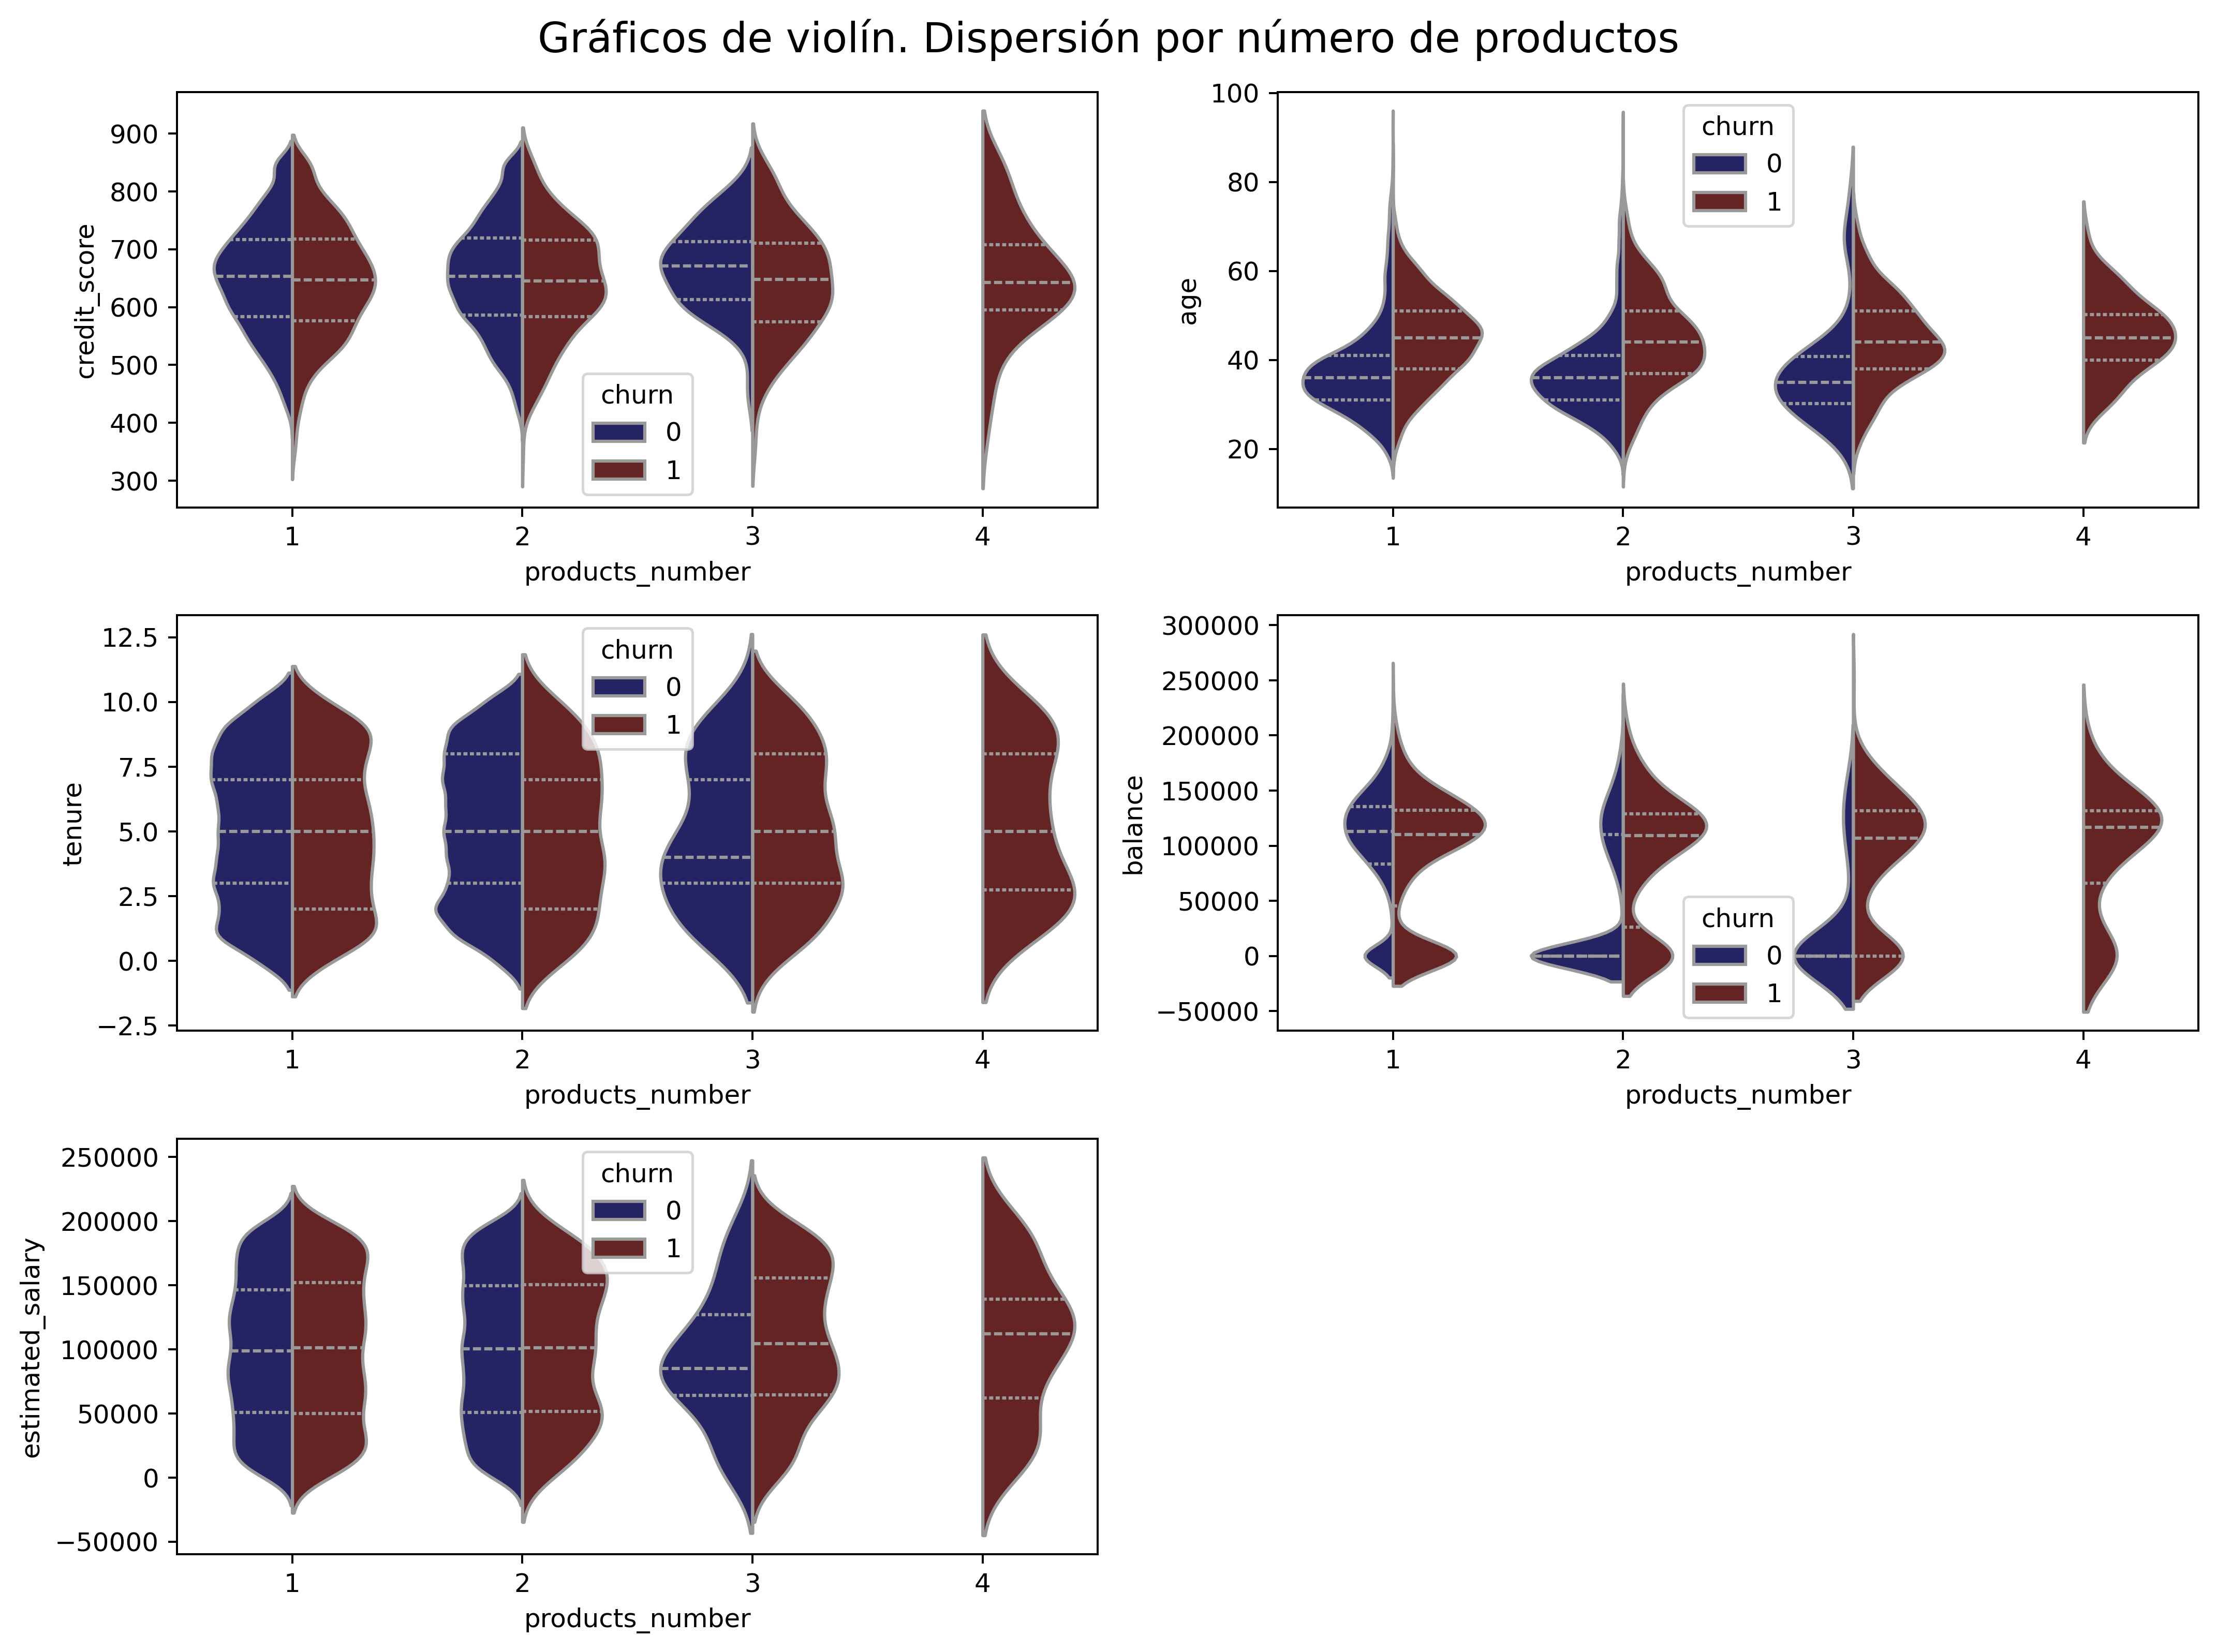

In [18]:
fig, axs = plt.subplots(nrows = 3, ncols = 2, dpi = 360, figsize = (12,9))
fig.suptitle('Gráficos de violín. Dispersión por número de productos', fontsize = 16)
for i, var in enumerate(numerical_vars):
    row, col = divmod(i,2)
    sns.violinplot(data=df_raw, y=var, hue ='churn' , x = 'products_number',
                   palette=churn_colors, split=True, inner='quart', fill = True, linecolor = '#999999', ax = axs[row, col])
    axs[row][col].set_ylabel(var)
fig.delaxes(axs[2, 1])
plt.tight_layout()
plt.show()

A partir de las gráficas se pueden establecer las siguientes observaciones:
- La más evidente: Todos los clientes que poseen 4 productos son clientes que han abandonado la institución en algún momento.
- El `credit_score` parece no tener relevancia para la asignación del número de productos.
- La variable `age` parece no tener relevancia para la asignación del número de productos.
- Los años de antigüedad `tenure` parece no tener relevancia para la asignación del número de productos.
- Existe un gran porcentaje de clientes que deciden abandonar el banco cuando tienen un sólo producto y no tienen saldo en su cuenta bancaria. Por su parte, la cantidad de saldo ingresado en cuenta (`balance`) parece no ser relevante para la asignación del número de productos para personas que no han abandonado, pues para clientes con 2 o 3 productos su saldo promedio es de $\$0$.
- El `estimated_salary` parece no tener relevancia para la asignación del número de productos.

En principio, no es posible determinar a simple vista que variables cambian para poseer una determinada cantidad de productos. Lo unico relevante de este análisis es que existe una gran deserción de clientes con un sólo producto y que la mayoría de clientes que no han abandonado, y que tienen saldo $\$0$ poseen gran cantidad de productos, a comparación de clientes han abandonado que parece una tendencia más normal.

*Se sugiere implementar un modelo que permita determinar cómo se están asignando los numeros de productos ya que, en principio, parecen otorgarse de manera independiente. Además, sería conveniente tener una variable adicional que permita identificar que clientes abandona la institución y posteriormente se vuelven a incorporar para observar las métricas que cambia el banco con estos. Se sugiere el uso de variables binarias para determinar si el cliente tiene un servicio en especifico en lugar de número de productos*

### Análisis de variables categóricas

In [19]:
categorical_vars = ['country', 'gender', 'credit_card', 'active_member']

#### Gráfica de barras

Se graficará una figura de barras para cada una de las variables categóricas, separadas en su respectivas clase (abandono o permanencia), lo cual permitirá analizar su distribución de datos.

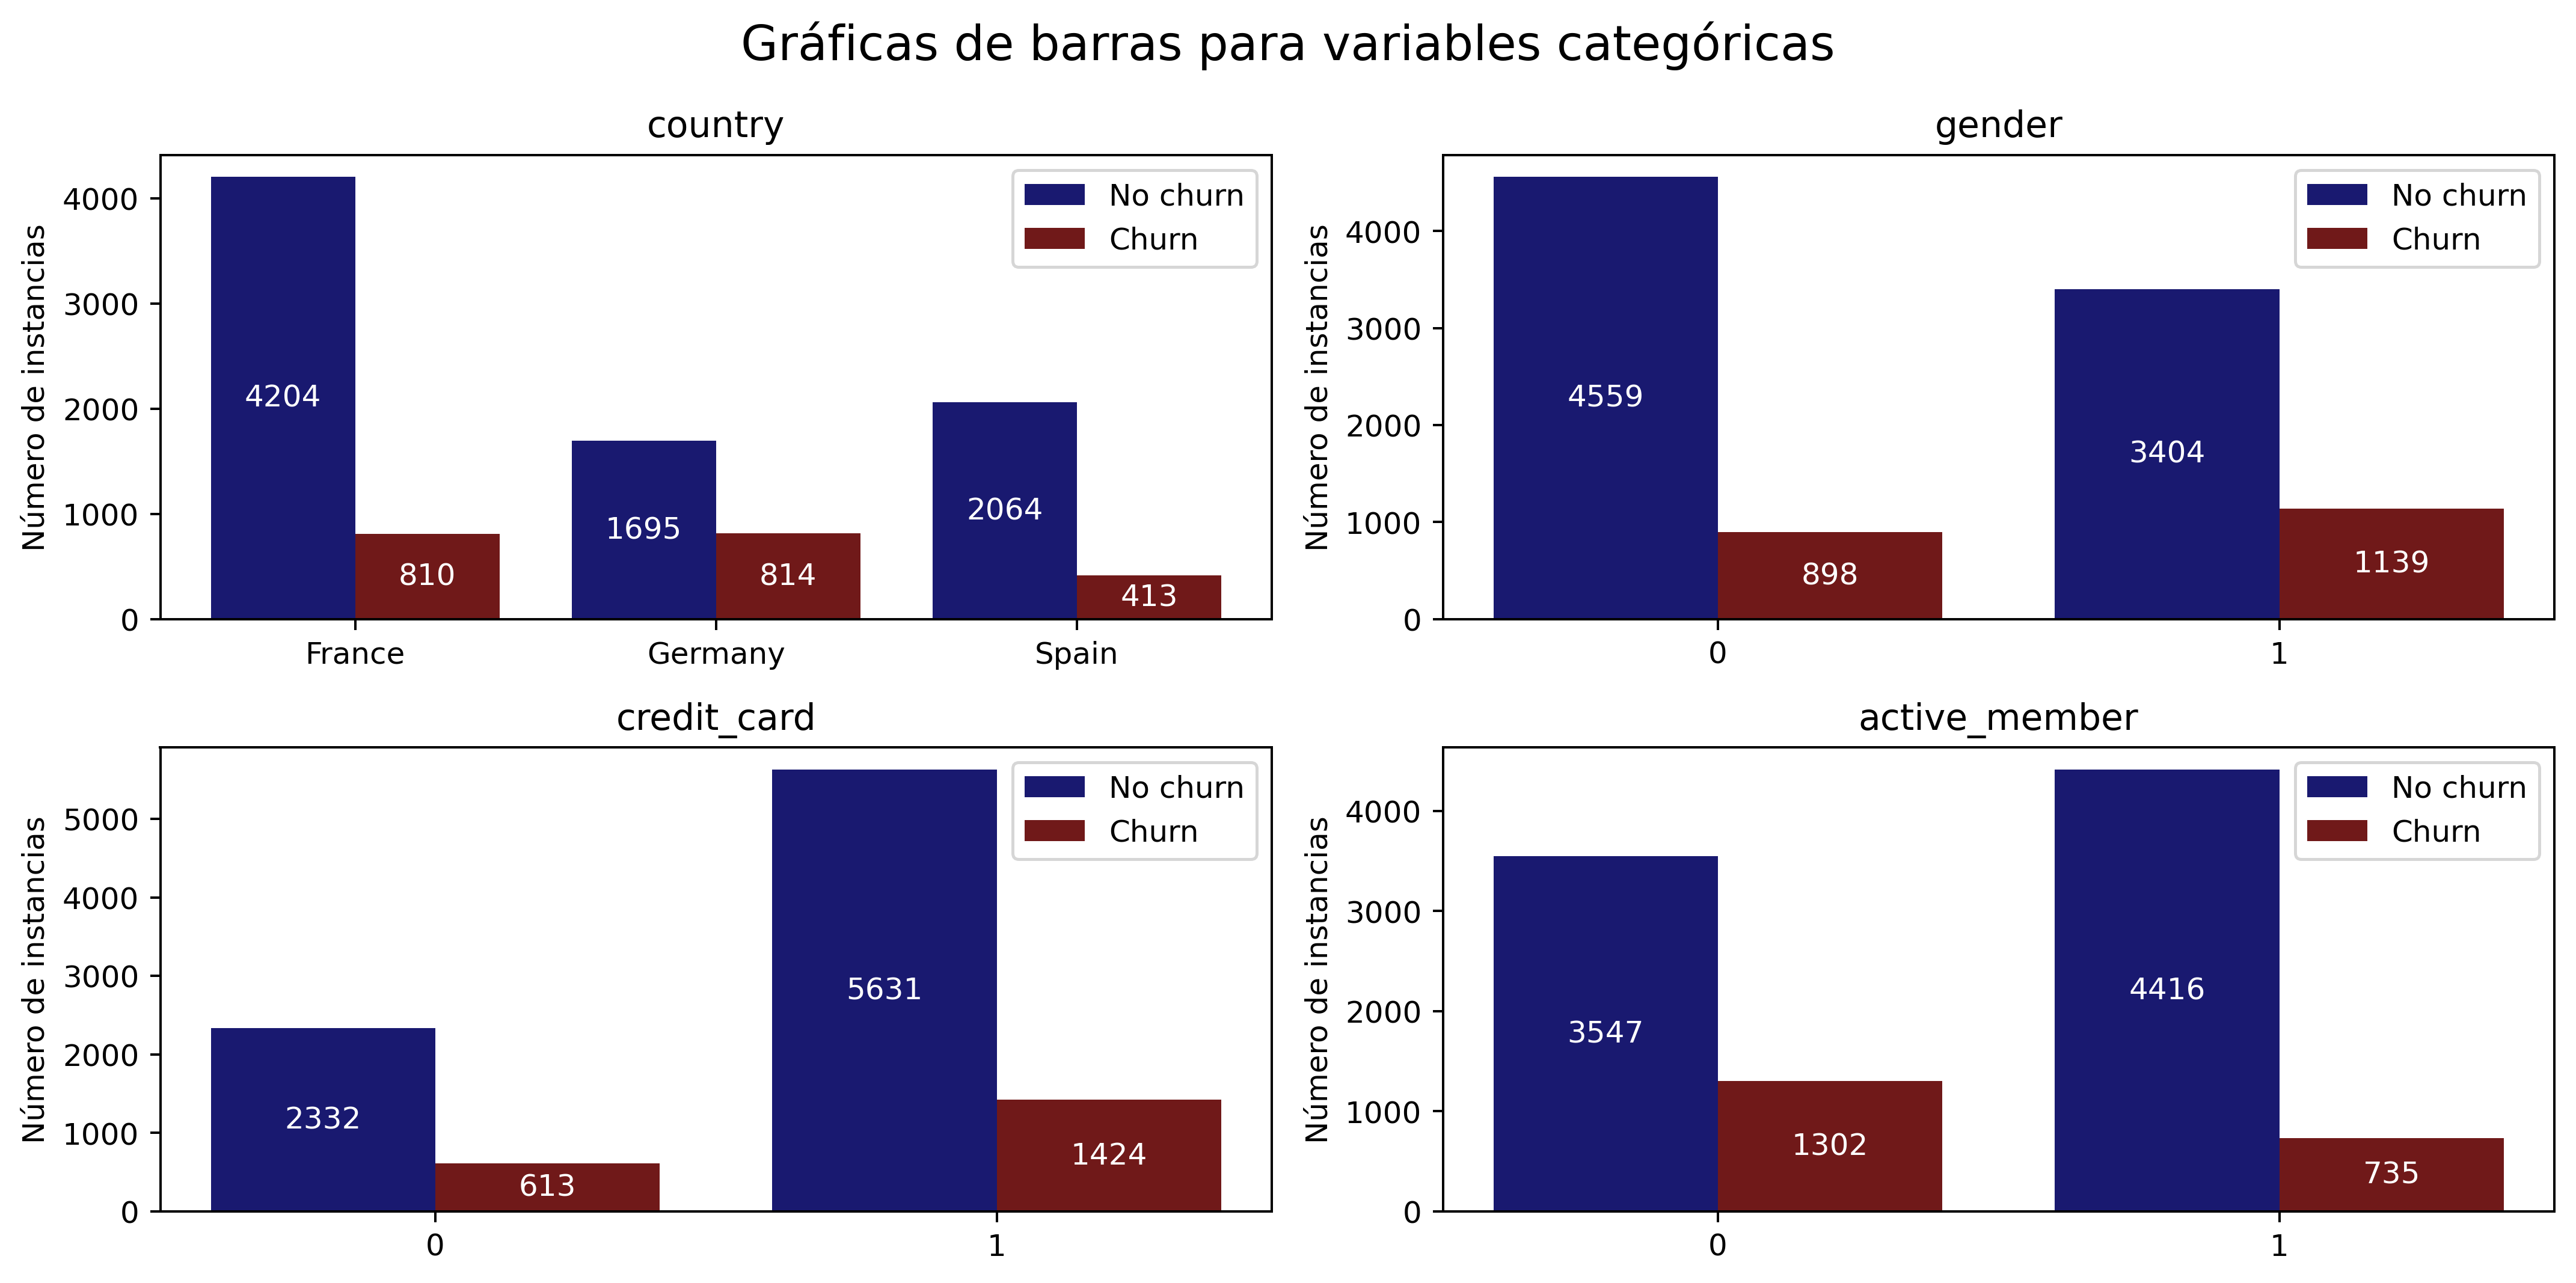

In [20]:
width = 0.4
fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (12,6), dpi = 360)
for i, var in enumerate(categorical_vars):
    row, col = divmod(i,2)
    classes = np.sort(df_raw[var].unique()).tolist()
    data = np.zeros(len(classes))
    x_pos = np.arange(len(classes))
    for churn in range(2):
        for j, label in enumerate(classes):
            data[j] = ((df_raw[var]==label) & (df_raw['churn']==churn)).sum()
        offset = width * churn
        label_churn = 'Churn' if churn else 'No churn'
        p = axs[row,col].bar(x_pos + offset, data, width, label = label_churn, color = churn_colors[churn])
        axs[row, col].bar_label(p, fmt='%.0f', label_type='center', color = 'White')
    axs[row,col].set_title(var)
    axs[row,col].set_ylabel('Número de instancias')
    axs[row,col].set_xticks(x_pos + width/2, classes)
    axs[row,col].legend()
plt.suptitle('Gráficas de barras para variables categóricas', fontsize = 16)
plt.tight_layout()
plt.show()

De igual forma que se hizo con las variables continuas, a partir de las gráficas de barras se extraerán algunas observaciones relevantes sobre el comportamiento de los clientes que abandonan o permanecen en la institución financiera. A continuación, se presentan los principales hallazgos junto con preguntas que permitirán realizar un análisis estadístico posterior:

**Diferencias por país de origen:** La mayor cantidad de clientes provienen de Francia, siendo España el país con menos clientes inscritos al banco. Sin embargo, se observa que las proporiciones para de abandono y permanencia en Francia y España es la misma (aproximadamente una relación de abandono 1:5), sin embargo esto cambia para alemania, teniendo más clientes que abandonan (aproximadamente una relación 1:2)
- ¿Es posible afirmar estadísticamente que los clientes alemanes suelen abandonar más que los otros clientes?
- ¿La tasa de abandono entre clientes de Francia y España es equivalente entre ellas?

**Variaciones por género:** Si bien, la mayoría de clientes son del género masculino, el porcentaje de hombres que abandonan la institución es menor que el procentaje de mujeres que abandonan.
- ¿Estadísticamente existe una diferencia entre el porcentajes de mujeres y hombres que abandonan?

**Posesión de tarjeta de credito:** Un gran porcentaje de clientes tiene tarjeta de crédito, sin embargo, se debe revisar si las proporciones son similares entre clientes que tienen y abandonan y clientes que no tienen y abandonan.
- ¿Estadísticamente las proporciones son distintas para la variable de `credit_card`?

**Actividad y abandono:** Los clientes que se consideran activos poseen una bajo porcentaje de abandono, por el contrario, los clientes que no son considerados activos tienen una mayor tendencia al abandono, a pesar de que el conjunto 'No activo' es menor.
- ¿Es la variable de actividad útil para predecir si un cliente abandonará o no la institución?

#### Gráfica de barras apiladas
Para poder descubrir patrones y factores que contribuyen en mayor medida al abandono de manera visual, se realizarán figuras de gráfica de barras apiladas las cuales permitirán observar las diferencias entre las proporciones en distintas variables y clases.

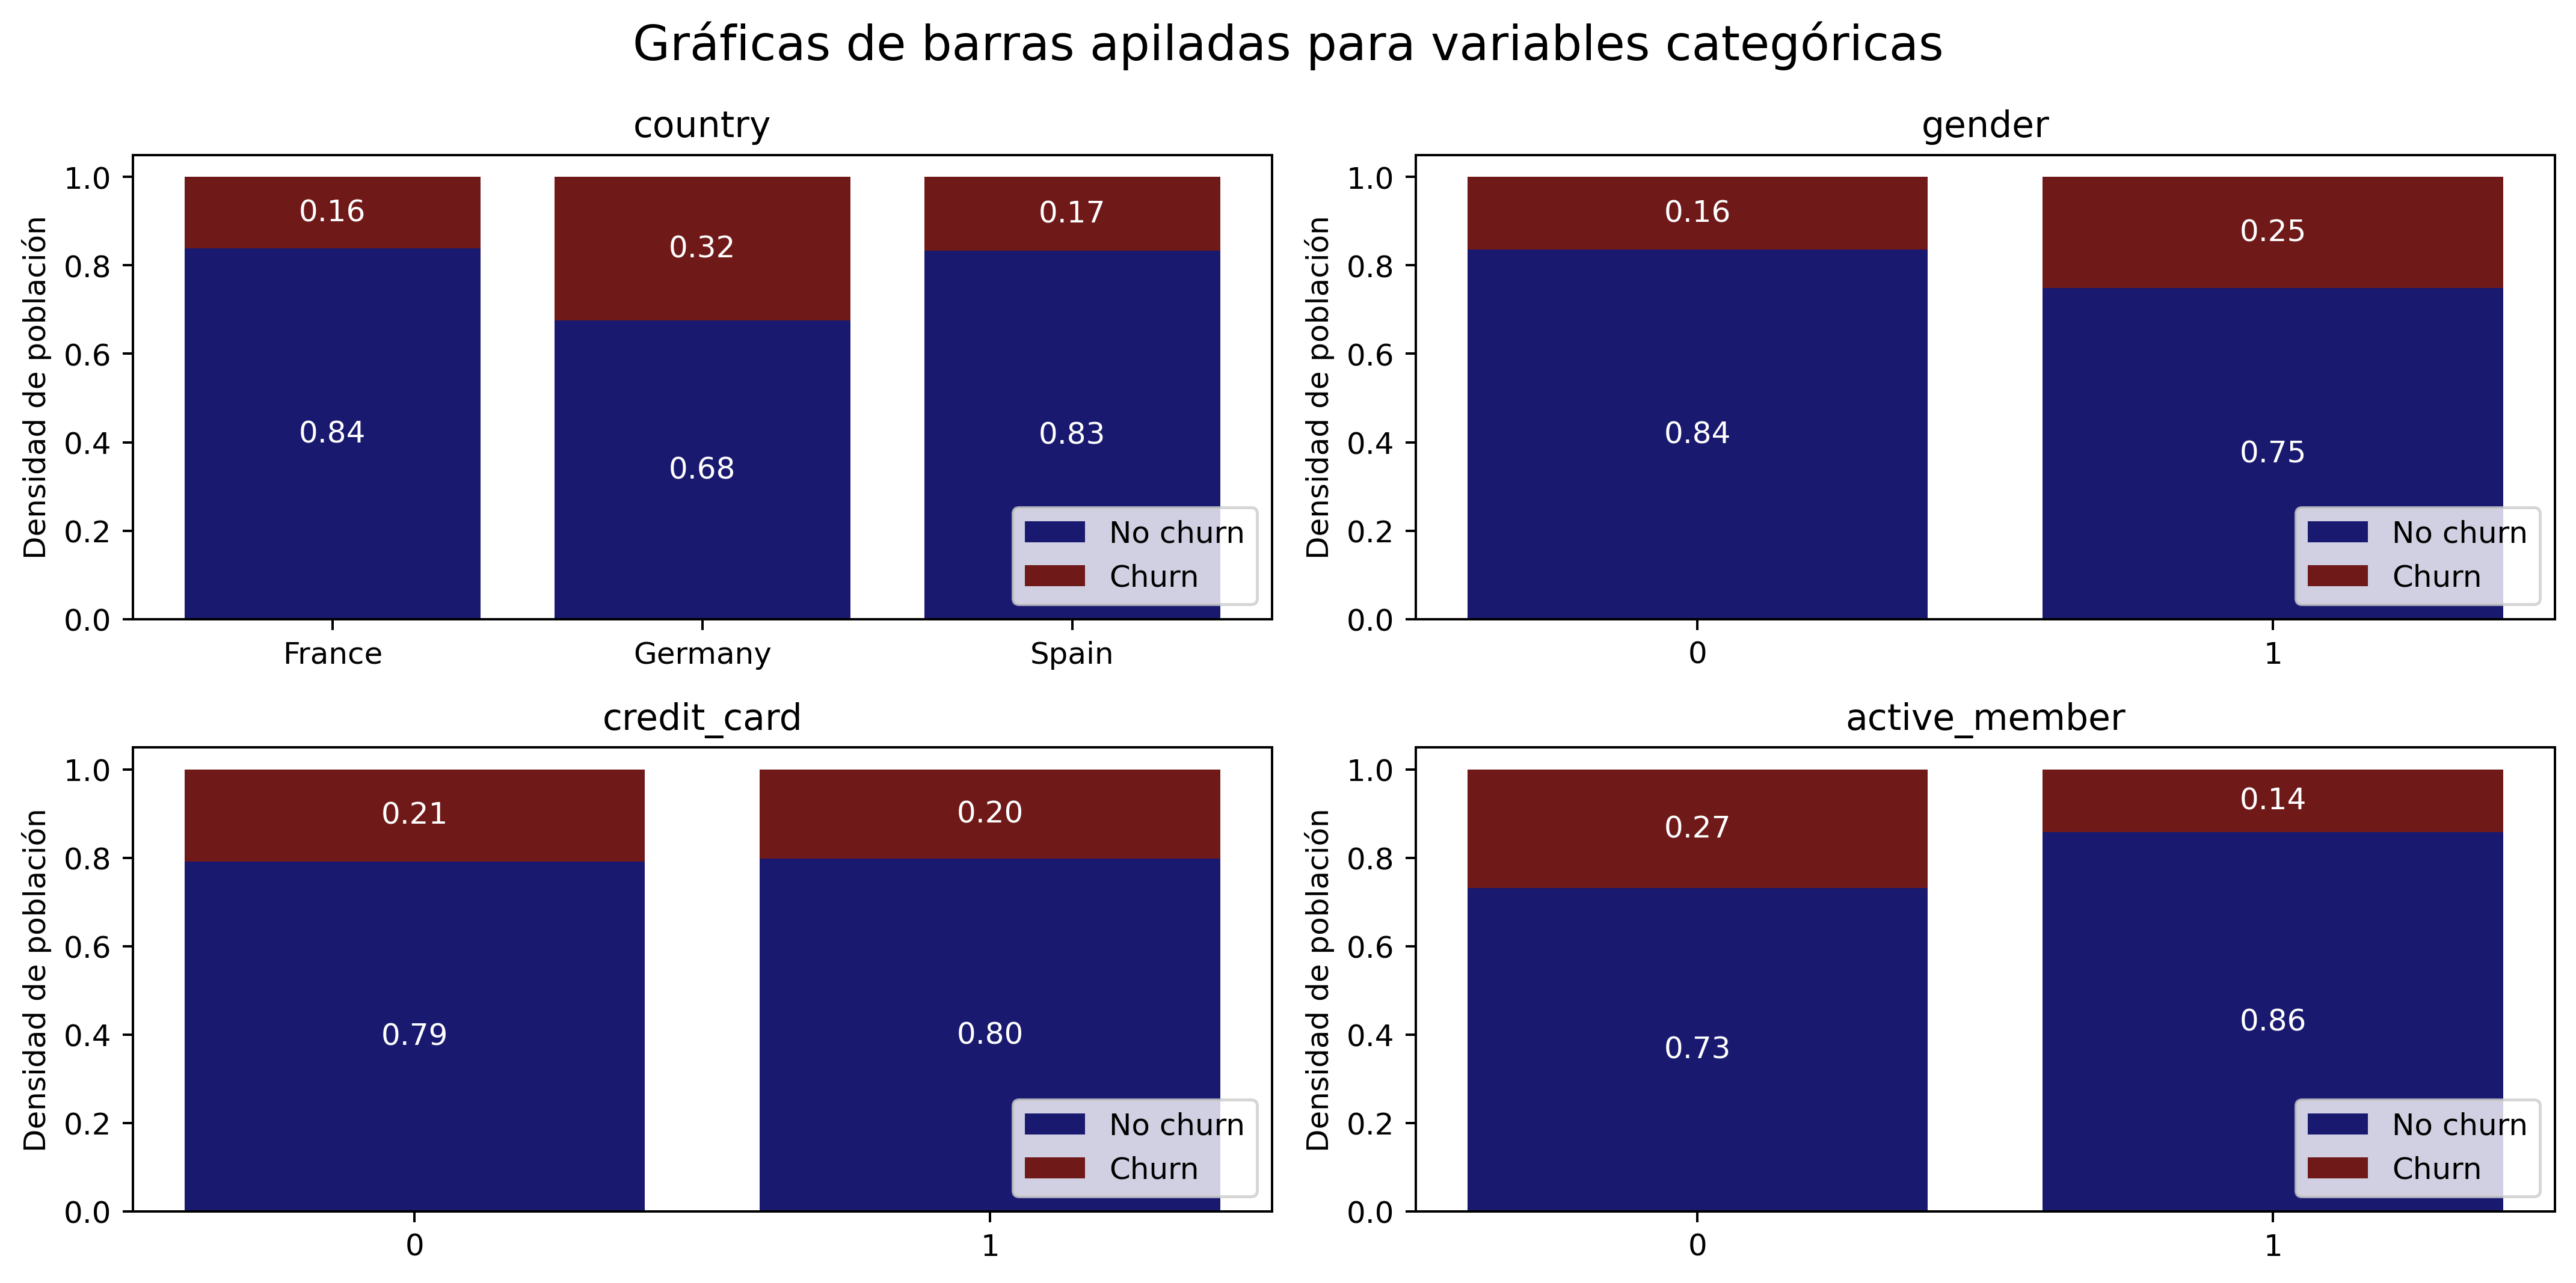

In [21]:
width = 0.8

fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (12,6), dpi = 360)
for i, var in enumerate(categorical_vars):
    row, col = divmod(i,2)
    classes = np.sort(df_raw[var].unique()).tolist()
    data = np.zeros((2, len(classes)))
    x_pos = np.arange(len(classes))
    bottom = np.zeros(len(classes))
    for j, label in enumerate(classes):
        data[0,j] = ((df_raw[var]==label) & (df_raw['churn']==0)).sum()
        data[1,j] = ((df_raw[var]==label) & (df_raw['churn']==1)).sum()
    data = data/data.sum(axis = 0)
    for j in range(2):
        label_churn = 'Churn' if j else 'No churn'
        p = axs[row,col].bar(x_pos, data[j,:], width, label = label_churn, color = churn_colors[j], bottom = bottom)
        bottom += data[j,:]
        axs[row, col].bar_label(p, fmt='%.2f', label_type='center', color = 'White')
    axs[row,col].set_title(var)
    axs[row,col].set_ylabel('Densidad de población')
    axs[row,col].set_xticks(x_pos, classes)
    axs[row,col].legend(loc="lower right")
plt.suptitle('Gráficas de barras apiladas para variables categóricas', fontsize = 16)
plt.tight_layout()
plt.show()

Con estas gráficas se pueden observar como se distribuyen las proporciones de clases en las distintas variables, lo que permite realizar las siguientes observaciones:
- Se observa que la mayor proporción de clientes que abandonan son clientes de Alemania, mientras que la proporción de Francia y España es similar entre estas y menor a la de Alemania.
- Se observa que las mujeres tienden a abandonar más la institución bancaria que los hombres.
- Parece ser que poseer tarjeta de credito no afecta la permanencia de clientes.
- La proporción de clientes que abandonan es más grande en los clientes inactivos que activos.

Si bien, es posible destacar estos patrones de manera visual, es necesario realizar un análisis estadístico que valide dichas afirmaciones. Estas pruebas estadísticas se realizarán en las siguientes secciones.

### Resumen de análisis exploratorio preliminar

A continuación, se presenta un resumen de los principales *insights* encontrados a partir del análisis exploratorio:
1. Se observa una similitud entre las distribuciones de clases para las variables `credit_score`, `tenure` y `estimated_salary`
2. La media de edad de las personas que abandonan es mayor a la media de edad de las personas que permanecen.
3. Existe una gran concentración de personas con un saldo de $\$0$ en sus cuentas, siendo en mayor proporción aquellos que tienden a permanecer más
en el banco. Por otro lado, para quienes tienen un saldo mayor a $\$0$ parece no existir diferencias en la distribución.
4. Solo las personas que han abandonado poseen 4 productos, mientras que aquellos clientes que permanecen y tienen $0 en su cuenta tienden a
tener más productos. Se observa que un gran porcentaje de clientes que abandonan tienen un solo producto. *Como sugerencia para implementación a
futuro debe considerarse utilizar esta variable como categórica para idetificar los producto que el cliente posee y revisar de mejor manera las tendencias. También se sugiere implementar una nueva variable que permita identificar si el cliente a abandonado y regresado a la institución*.
5. Los clientes alemanes presentan una mayor tasa de abandono.
6. Existe una mayor cantidad de clientes masculinos, pero la tasa de abandono es más alta en mujeres.
7. Alrededor del 70\% de clientes poseen tarjeta de credito. No es posible marcar una tendencia clara con esta variable.
8. Los clientes considerados como inactivos suelen tener una tasa de abandono más alta.	 

## Partición de los datos

Dado que los datos se encuentran desbalanceados, es necesario realizar una partición estratificada. Para ello, se utilizará la implementación `train_test_split`de *sklearn*, utilizando una partición 85-15.

In [22]:
from sklearn.model_selection import train_test_split

SEED = 123
np.random.seed(SEED)

X = df_raw.drop(columns = ['churn'])
y = df_raw['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=SEED)

## Pruebas estadísticas sobre train set

Como se mencionó en el análisis exploratorio, es necesario realizar algunas pruebas estadísticas sobre los datos para validar hipotesis y describir variables que sirvan para predecir el abandono de clientes. Para ello, el conjunto de datos se dividirá en dos conjuntos de datos: clientes que han abandonado y clientes que permanecen en la institución.

In [23]:
X_NoChurn= X_train[y_train == 0]
X_Churn = X_train[y_train == 1]

### Similitud en distribución: Kolmogorov-Smirnov dos muestras

Se empezará realizando la prueba de *kolmogorov-Smirnov* para comparar las distribuciones de los datos para las distintas variables numéricas.

Se propone como hipotesis nula H0 que no existe diferencia significativa entre las distribuciones para clientes que han abandonodo y que permancen en la institución para una determinada variable. Esta prueba se realizará con una significancia del 1%.

In [24]:
print('-----Prueba Kolmogorov-Smirnov de dos muestras-----')
for var in numerical_vars:
    res = stats.ks_2samp(X_NoChurn[var], X_Churn[var])
    print(f"{var}: p-value = {res.pvalue:.4f}")

-----Prueba Kolmogorov-Smirnov de dos muestras-----
credit_score: p-value = 0.0099
age: p-value = 0.0000
tenure: p-value = 0.0869
balance: p-value = 0.0000
estimated_salary: p-value = 0.5874


Con lo anterior, se obtiene que estadísticamente no hay diferencia significativa entre la distribución de datos de `tenure` y `estimated_salary` para clientes con y sin abandono. Las demás variables numéricas sí presentan diferencias significativas entre las distribuciones de datos para los dos tipos de clientes.

### Tendencias de valores: Mann-Whitney U

Una prueba no paramétrica para analizar si dos conjuntos de datos presentan una la tendencia estadisticamente distinta, es la prueba de *Mann-Whitney U*. Esta prueba no es la alternativa no paramétrica de la prueba t, sin embargo, puede ser utilizado de manera aproximada. 

Se establece como hipótesis nula H0 que la tendencia entre los dos grupos para una determinada variable es la misma. Implementando esta prueba para cada una de las variables numéricas se obtiene lo siguiente:

In [25]:
print('-----Prueba Mann–Whitney U-----')
for var in numerical_vars:
    res = stats.mannwhitneyu(X_NoChurn[var], X_Churn[var])
    print(f"{var} p-value = {res.pvalue:.4f}")

-----Prueba Mann–Whitney U-----
credit_score p-value = 0.0067
age p-value = 0.0000
tenure p-value = 0.0262
balance p-value = 0.0000
estimated_salary p-value = 0.4205


La prueba de *Mann-Whitney U* indica que no existen diferencias significativas entre las tendencias de los datos en clientes con abandono y cliente que permanencen para las variables numéricas `tenure` y `estimated_salary`. Por su parte, las demás variables sí presentan una tendencia significativamente diferente entre los dos grupos.

### Saldo en cuentas de clientes

#### Clientes con saldo en cuenta

Como se mencionó en el análisis exploratorio, existe una gran concentración de clientes que poseen $\$0$ en sus cuentas, siendo mayor la proporción de clientes que permanecían que los que abandonaban. Al filtrar los clientes que tienen saldo en su cuenta, se encontró que la distribución entre grupos era casi normal y muy parecida entre sí. Es por ello que se desea saber si la media, y en general, las distribuciones de los clientes que tienen saldo en sus cuentas es distinta para las dos clases. 

Se realiza el filtrado de datos y se obtienen los clientes que sí tienen saldo en sus cuentas:

In [26]:
X_NonZero_NoChurn = X_NoChurn[X_NoChurn['balance']>0]['balance']
X_NonZero_Churn = X_Churn[X_Churn['balance']>0]['balance']

Para comparar las medias, se debe revisar si el conjunto de datos sigue una distribución normal. Para ello, se realizará una prueba de Shapiro.

In [27]:
res_NoChurn = stats.shapiro(X_NonZero_NoChurn)
res_Churn = stats.shapiro(X_NonZero_Churn)
print('-----Prueba Shapiro para normalidad-----')
print(f'p-value para balance de clientes que permanecen: {res_NoChurn.pvalue:.4f}')
print(f'p-value para balance de clientes que abandonan: {res_Churn.pvalue:.4f}')

-----Prueba Shapiro para normalidad-----
p-value para balance de clientes que permanecen: 0.9171
p-value para balance de clientes que abandonan: 0.0000


Dado que los dos grupos no siguen una distribución normal, es necesario aplicar una prueba no paramétrica. Debido a esto, se utilizarán las pruebas anteriormente aplicadas para comparar la distribución y tendencia del saldo entre las clases. 

Se establece como hipotesis nula H0 que no existe diferencia significativa entre la distribución y tendencia del balance para clientes que abandonan y permanecen.

In [28]:
res = stats.ks_2samp(X_NonZero_NoChurn, X_NonZero_Churn)
print(f"KS: p-value = {res.pvalue:.4f}")
res = stats.mannwhitneyu(X_NonZero_NoChurn, X_NonZero_Churn)
print(f"MWU: p-value = {res.pvalue:.4f}")

KS: p-value = 0.0009
MWU: p-value = 0.0989


Como se puede observar, los datos tienen una distribución significativamente distinta (prueba Kolmogorov-Smirnov), mientras que la tendencia parece no ser significativamente distinta (prueba Mann-Whitney U).

Para comparar esto visualmente, se graficará el histograma y la función de distribución de probabilidad

In [29]:
n = X_Churn.shape[0] + X_NoChurn.shape[0]

n_bins = 1+ np.log2(n) #Regla de Sturges y redondeo
if 0.5 > n_bins - np.floor(n_bins):
    n_bins = int(np.floor(n_bins))
else:
    n_bins = int(np.ceil(n_bins))
    
min_train_balance = X_train['balance'].min()
max_train_balance = X_train['balance'].max()

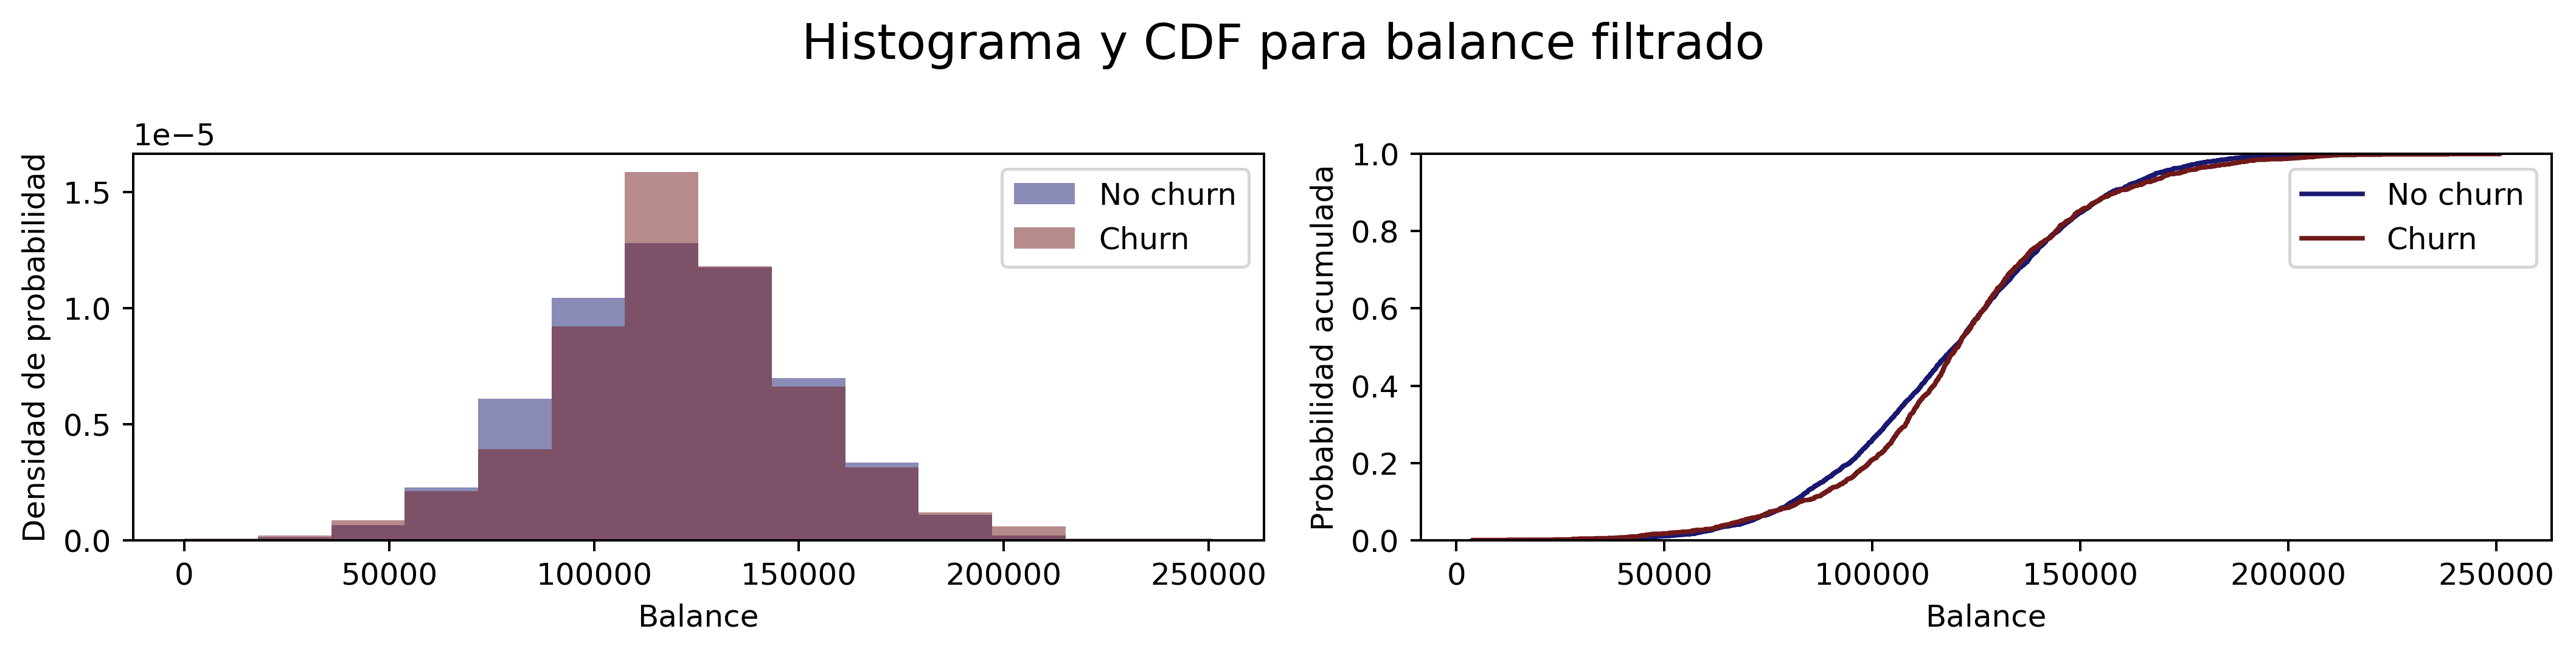

In [30]:
fig, axs = plt.subplots(nrows=1, ncols=2, dpi=360, figsize=(12, 3))
fig.suptitle('Histograma y CDF para balance filtrado', fontsize = 16)
axs[0].hist(X_NonZero_NoChurn, bins=n_bins, range=[min_train_balance, max_train_balance], density = True,
            label="No churn", color=churn_colors[0], alpha = 0.5)
axs[0].hist(X_NonZero_Churn,   bins=n_bins, range=[min_train_balance, max_train_balance], density = True,
            label="Churn", color=churn_colors[1], alpha = 0.5)
axs[0].set_xlabel("Balance")
axs[0].set_ylabel("Densidad de probabilidad")
axs[0].legend()
sns.ecdfplot(X_NonZero_NoChurn, ax=axs[1], color=churn_colors[0], label="No churn")
sns.ecdfplot(X_NonZero_Churn, ax=axs[1], color=churn_colors[1], label="Churn")
axs[1].set_xlabel("Balance")
axs[1].set_ylabel("Probabilidad acumulada")
axs[1].legend()
plt.tight_layout()
plt.show()

Como se puede observar, el histograma muestra la tendencia central de los datos, los cuales se encuentran centrados en el intervalo entre $\$100000$ y $\$140000$. Por otro lado, la gráfica CDF presenta diferencias entre las distribuciones de los datos. Debido a que no es muy clara la diferencia entre los datos, considerar clientes con un saldo mayor a 0 no permite separar correctamente las clases.

#### Clientes sin saldo en cuenta

Ahora, es momento de analizar si existen diferencias significativas entre el número de clientes que poseen un saldo de $\$0$ en sus cuentas. Para ello, se realizará una prueba $Z$ para proporciones. Para esto, se define la función `z_proportions`.

In [31]:
def z_proportions(n1, n2, x1,x2):
    p = (x1 + x2)/(n1+n2)
    p1 = x1/n1
    p2 = x2/n2
    Z = (p1-p2)/np.sqrt(p*(1-p)*(1/n1+1/n2))
    pvalue = 2*stats.norm.sf(abs(Z))
    res = {'statistics': Z,
            'pvalue': pvalue}
    return res

Para realizar esta prueba, se seleccionan las instancias que cumplen una determinada condición, en este caso, se seleccionan los $x_i$ clientes que no tienen saldo, es decir, tienen un total de $\$0$ en cuenta, para cada una de las $i$ clases (permanencia y abandono). Por otro lado, es necesario comparar con respecto al tamaño $n_i$ al que pertenece cada clase.

Para esta prueba, se toma como hipotesis nula H0 que no existen diferencias significativas entre las proporciones de ambos grupos. Realizando la prueba estadística con una significancia del 5% se obtiene lo siguiente:

In [32]:
n1, n2= X_NoChurn.shape[0], X_Churn.shape[0]
x1, x2 = (X_NoChurn['balance']==0).sum(), (X_Churn['balance']==0).sum()

res = z_proportions(n1,n2,x1,x2)
print(f"pvalue: {res['pvalue']:.4f}")

pvalue: 0.0000


Dado que el pvalue es menor, se concluye que sí existen diferencias significativas entre las proporciones de clientes que tienen un saldo de $\$0$ para aquellos que abandonan o permanecen. Debido a esto, se agregará una variable categórica que permitirá identificar cuando un cliente posea un balance activo o inactivo, la cual se denominará `active_balance`.

In [33]:
X_train['active_balance'] = (X_train['balance'] > 0).astype(int)
X_test['active_balance'] = (X_test['balance'] > 0).astype(int)

X_NoChurn= X_train[y_train == 0]
X_Churn = X_train[y_train == 1]

### Correlaciones entre variables

Para observar si existen correlaciones entre las distintas variables numéricas, se realizará una grafica de correlaciones para observar patrones en los distintos grupos de clientes.

In [34]:
numerical_vars = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']

corr_churn = X_Churn[numerical_vars].corr()
corr_no_churn = X_NoChurn[numerical_vars].corr()

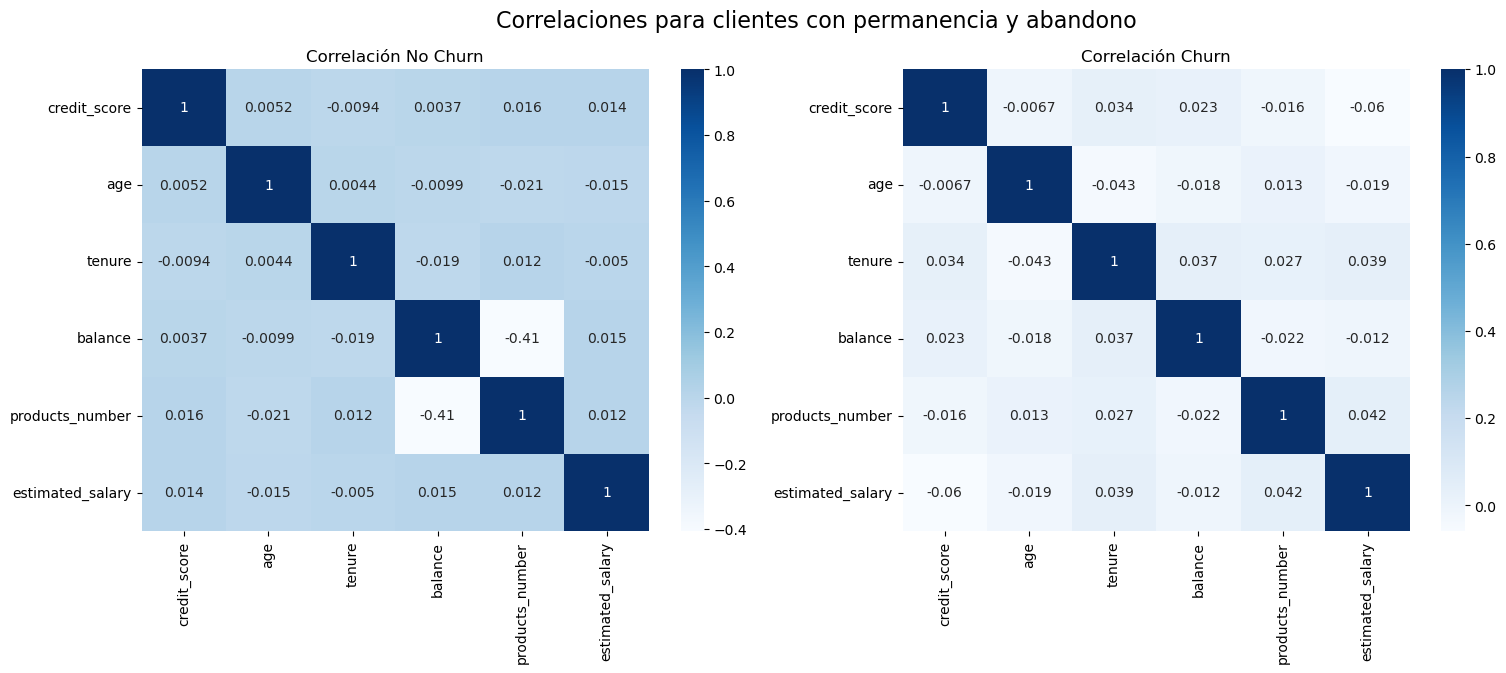

In [35]:
fig, axs = plt.subplots(1, 2, figsize=(18,6))
plt.suptitle('Correlaciones para clientes con permanencia y abandono', fontsize = 16)
sns.heatmap(corr_no_churn, annot=True, cmap='Blues', ax=axs[0])
axs[0].set_title('Correlación No Churn')
sns.heatmap(corr_churn, annot=True, cmap='Blues', ax=axs[1])
axs[1].set_title('Correlación Churn')
plt.show()

Como se puede observar, la única variable que parece estar correlacionada de manera descendente es el número de productos y balance para las personas que no han abandonado. Esta correlación se puede observar en la figura del gráfico de violín donde se presentan las distribuciones por número de productos. Se observa que para el balance existe una asignación mayor de productos para aquellas cuentas que tienen un saldo de $\$0$. Sin embargo, como se mencionó, esto solo ocurre para las personas que no han abandonado. Parece no existir correlaciones claras para las demás variables en clientes que han abandonado. 

### Variables categóricas discriminantes: Prueba $\chi^2$

Una vez analizadas las distribuciones con las variables numéricas, se analizarán las distribuciones con las variables categóricas, para ello, se analizaran las diferencias entre grupos utilizando la prueba $\chi^2$.

In [36]:
categorical_vars = ['country', 'gender', 'credit_card', 'active_member', 'active_balance']

Se propone como hipótesis nula H0 que el estado del cliente (permanecer o abandonar) es independiente de la variable analizada.

In [37]:
for var in categorical_vars:
    tabla = pd.crosstab(X_train[var], y_train)
    chi2 = stats.chi2_contingency(tabla, correction=(tabla.shape == (2,2)))
    print(f"{var}: pvalue = {chi2.pvalue:.4f}")

country: pvalue = 0.0000
gender: pvalue = 0.0000
credit_card: pvalue = 0.3381
active_member: pvalue = 0.0000
active_balance: pvalue = 0.0000


Los resultados obtenidos indican que sólo `credit_card` es independiente del estado del cliente, mientras que para las demás variable sí existe un grado de dependencia entre que un cliente permanezca o abandone.

### Diferencias en proporciones

En la gráfica de barras apiladas, se observó que existían distintas proporciones de abandono para algunas variables categóricas. Se desea saber si las proporciones de clientes que han abandonado el banco son estadisticamente distintos al pertenecer a un conjunto para las distintas variables categóricas.

Se propone como hipótesis nula H0 que no existe diferencia significativa entre la proporción de clientes que han abandonado al pertenecer a una clase u otra para las distintas variables categóricas.

In [38]:
categorical_vars = ['gender', 'credit_card', 'active_member', 'active_balance']

En este caso, se omite la variable `country` dado que esta posee 3 clases.

In [39]:
for var in categorical_vars:
    n0 = (X_train[var]==0).sum()
    n1 = (X_train[var]==1).sum()
    x0 = (X_Churn[var]==0).sum()
    x1 = (X_Churn[var]==1).sum()
    res = z_proportions(n0, n1, x0,x1)

    print(f"{var}. pvalue: {res['pvalue']:.4f}")

gender. pvalue: 0.0000
credit_card. pvalue: 0.3234
active_member. pvalue: 0.0000
active_balance. pvalue: 0.0000


Como se puede observar, se obtienen resultados parecidos a la pruba $\chi^2$, lo cual fortalece los resultados que la variable `credit_card` no funciona como variable predictora.

#### Abandono en Francia y España

En el análisis exploratorio general, se observó que Alemania era el país que más abandonaba. Si bien, es posible realizar una prueba post hoc para determinar en que grupo existe la diferencia, se asumirá que se trata de Alemania. Se desea saber ahora si las proporciones de abandono entre Francia y España es la misma. 

Se asume como hipótesis nula H0 que no existe diferencia significativa en la proporción de clientes que han abandonado entre clientes de Francia y España.

In [40]:
n0 = (X_train['country'] == "Spain").sum()
n1 = (X_train['country'] == "France").sum()
x0 = (X_Churn['country'] == "Spain").sum()
x1 = (X_Churn['country'] == "France").sum()

res = z_proportions(n0, n1, x0,x1)

print(f"pvalue: {res['pvalue']:.4f}")

pvalue: 0.6297


Como se puede observar, no es posible descartar H0, por lo cual se establece que no existe diferencia significativa en la proporción de clientes que han abandonado entre clientes de Francia y España.

### Dependencia entre variables categóricas: Prueba $\chi^2$

Una relación interesante a analizar son las dependencias entre las distintas variables categóricas, de manera análoga a la correlación que se calculó entre variables numéricas. Para ello, se realizarán pruebas $\chi^2$ para cada una de las variables.

Se establece como H0 que la variable 1 y la variable 2 son estadisticamente independientes.

In [41]:
categorical_vars = ['country', 'gender', 'credit_card', 'active_member', 'active_balance']

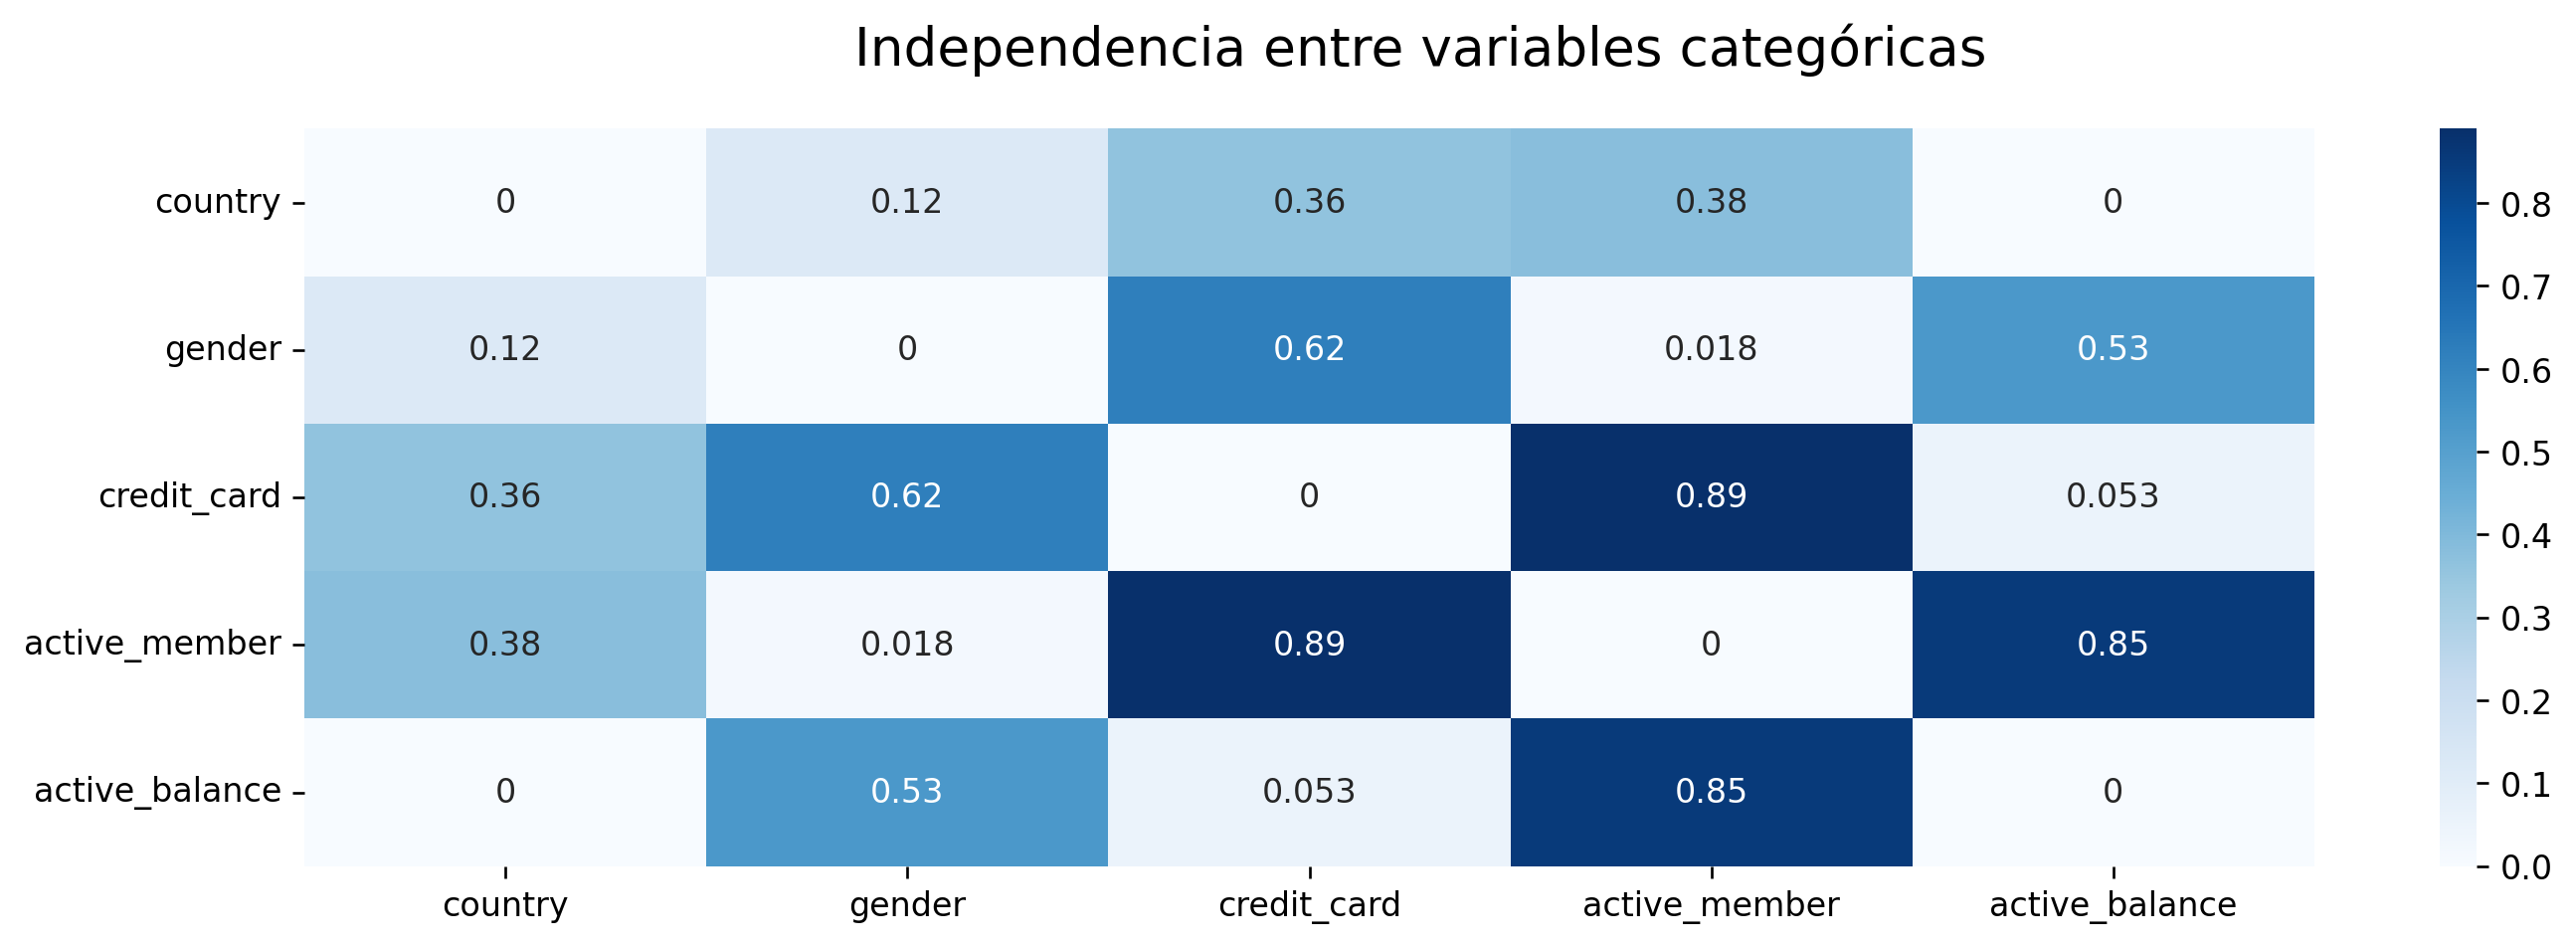

In [42]:
tabla = np.zeros((len(categorical_vars), len(categorical_vars)))

for row, var1 in enumerate(categorical_vars):
    for col, var2 in enumerate(categorical_vars):
        crosstab = pd.crosstab(X_train[var1], X_train[var2])
        chi2 = stats.chi2_contingency(crosstab, correction=True)
        tabla[row, col] = chi2.pvalue

plt.figure(figsize=(12, 4), dpi = 240)
plt.suptitle('Independencia entre variables categóricas', fontsize=16)
sns.heatmap(tabla, annot=True, cmap='Blues', xticklabels=categorical_vars, yticklabels=categorical_vars)
plt.tight_layout()
plt.show()

Con los resultados obtenidos, es posible establecer las siguientes conclusiones:
- Existe una dependencia entre el país y los clientes con un balance activo, lo que indicaría que hay una mayor proproción de clientes que tienen $\$0$ en sus cuentas en distintos países.
- Existe una dependencia entre el género y la variable de miembro activo. Existe un género que es más 'activo' que el otro.

Se graficará en una figura de barras apiladas los *insights* encontrados.

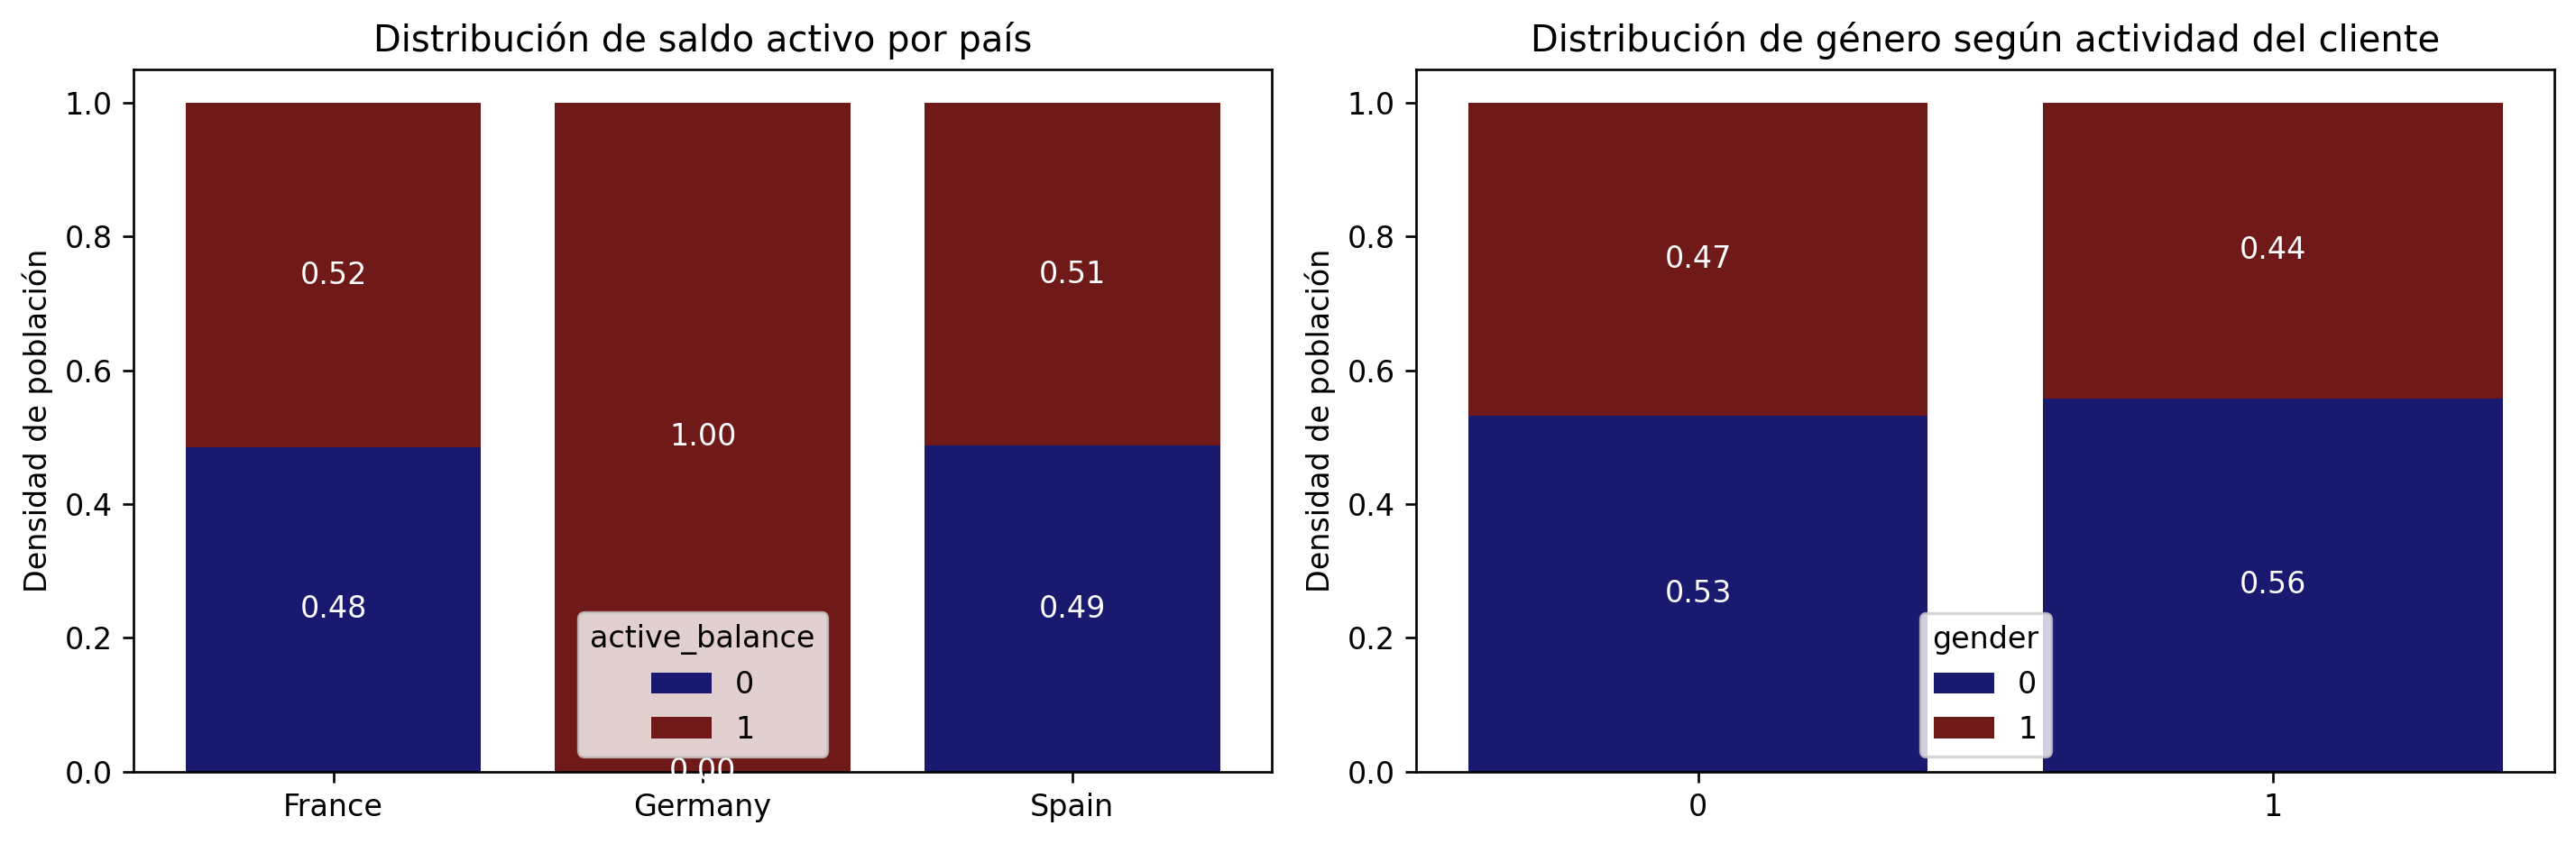

In [43]:
width = 0.8
fig, axs = plt.subplots(ncols=2, figsize=(12, 4), dpi=240)

# Country vs Active Balance 
classes = np.sort(X_train['country'].unique()).tolist()
x_pos = np.arange(len(classes))
data = np.zeros((2, len(classes)))
for j, label in enumerate(classes):
    data[0, j] = ((X_train['country'] == label) & (X_train['active_balance'] == 0)).sum()
    data[1, j] = ((X_train['country'] == label) & (X_train['active_balance'] == 1)).sum()
data = data / data.sum(axis=0)
bottom = np.zeros(len(classes))
for j in range(2):
    p = axs[0].bar(x_pos, data[j, :], width=width, bottom=bottom, label=str(j), color = churn_colors[j])
    bottom += data[j, :]
    axs[0].bar_label(p, fmt='%.2f', label_type='center', color = 'White')
axs[0].set_ylabel('Densidad de población')
axs[0].set_xticks(x_pos)
axs[0].set_xticklabels(classes)
axs[0].legend(title='active_balance', loc="lower center")
axs[0].set_title('Distribución de saldo activo por país')

#Active Member vs Gender
classes = np.sort(X_train['active_member'].unique()).tolist()
x_pos = np.arange(len(classes))
data = np.zeros((2, len(classes)))
for j, label in enumerate(classes):
    data[0, j] = ((X_train['active_member'] == label) & (X_train['gender'] == 0)).sum()
    data[1, j] = ((X_train['active_member'] == label) & (X_train['gender'] == 1)).sum()
data = data / data.sum(axis=0)
bottom = np.zeros(len(classes))
for j in range(2):
    p = axs[1].bar(x_pos, data[j, :], width=width, bottom=bottom, label=str(j), color = churn_colors[j])
    bottom += data[j, :]
    axs[1].bar_label(p, fmt='%.2f', label_type='center', color = 'White')
axs[1].set_ylabel('Densidad de población')
axs[1].set_xticks(x_pos)
axs[1].set_xticklabels(classes)
axs[1].legend(title='gender', loc="lower center")
axs[1].set_title('Distribución de género según actividad del cliente')

plt.tight_layout()
plt.show()


A partir de las gráficas de barras apiladas. se observa lo siguiente:
- Todos los clientes de Alemania tienen un saldo activo en sus cuentas, mientras que, aproximadamente solo la mitad de clientes de Francia y España tienen sus saldos activas.
- Los clientes hombres suelen ser miembros más activos que las mujeres. 

### Resumen de pruebas estadísticas

A continuación se presenta un resumen de los resultados obtenidos a partir de las pruebas estadísticas realizadas.
- No se muestra una diferencia significativa entre la distribución y tendencia de la variable `tenure` en clientes que abandonan y permanecen.
- No se muestra una diferencia significativa entre la distribución y tendencia de la variable `estimated_salary` en clientes que abandonan y permanecen.
- Si bien, la distribución de `balance` en clientes con saldo en su cuentas es distinto en ambos grupos, la tendencia es la misma.
- Se agregó la variable `active_balance`la cual indica si un cliente posee o no saldo en su cuenta. Se encontró que la proporción de clientes con saldo $\$0$ es mayor en aquellos que permanecen que los que se van.
- Se encontró una correlación de negativa significante entre el número de productos y el balance para clientes que no han abandonado la institución. En el análisis exploratorio se observó una gran proporción de clientes con saldo $\$0$ y que cuentan con 3 productos.
- No se muestra una relación con la variable `credit_card` significativa en clientes que abandonan y permanecen.
- No se encontró una diferencia significativa entre la proporción de clientes abandonan y que cuentan con `credit_card` o no.
- La proporción de clientes alemanes que abandonan es mayor a la proporción de clientes españoles y franceses que abandonan. La proporción de clientes españoles y franceces que abandonan estadísticamente es la misma.
- Todos los clientes alemanes tienen su balance activo, es decir, cuentan con dinero ingresado en cuenta. 
- Los clientes hombres suelen considerarse clientes más activos que las clientas mujeres.

A continuación se utilizarán algunas técnicas que permitirán transformar los datos para un mejor manejo de estos así como la selección de variables para el diseño de los modelos.

## Transformación de datos

Previo a la transformación de los datos, es necesario generar una copia que permita recuperar los datos originales en caso de que se requieran hacer otras transformaciones. Para ello, se realiza lo siguiente:

In [44]:
# Generando copia datasets
X_train_base = X_train.copy()
X_test_base = X_test.copy()

Es necesario transformar los datos para evitar que los modelos se saturen debido a una diferencia de magnitudes para alguna variable. De igual forma, la variable `country` debe ser codificada como *one-hot encoding* para usarla correctamente.

Para escalar los datos, es posible utilizar dos métricas distintas: *normalización* y *estandarización*. En este caso se generan ambos escaladores para utilizarlos a conveniencia. 

In [45]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler

# Generando escaladores
scalerMinMax = MinMaxScaler()
scalerStandard = StandardScaler()

# Generando encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [46]:
# Inicializando OHE
encoder.fit(X_train[['country']])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

Para tener reproducibilidad de los datos, y ser utilizados a conveniencia, se realizó la función `transform_data`. Esta función recibe el escalador y el encoder a utilizar, así como las variables que se modificarán en  el dataset.

In [47]:
def transform_data(df, scaler, encoder, column_name, scale_vars):
    df[scale_vars] = scaler.transform(df[scale_vars])
    encoded = encoder.transform(df[[column_name]])
    encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out([column_name]), index=df.index).astype(int)
    df_transformed = pd.concat([df.drop(columns=[column_name]), encoded_df], axis=1)
    df_transformed = df_transformed.sort_index(axis=1)
    return df_transformed

In [48]:
X_train = X_train_base.copy()
X_test = X_test_base.copy()

#scalerMinMax.fit(X_train[numerical_vars])
scalerStandard.fit(X_train[numerical_vars])

StandardScaler()

In [49]:
# Transformando data
X_train = transform_data(X_train, scalerStandard, encoder, 'country', numerical_vars)
X_test = transform_data(X_test, scalerStandard, encoder, 'country', numerical_vars)

A continuación se muestra cómo se distribuyen las distintas variables en el conjunto de entrenamiento.

In [50]:
X_train.head()

,active_balance,active_member,age,balance,country_France,country_Germany,country_Spain,credit_card,credit_score,estimated_salary,gender,products_number,tenure
490,1,1,-0.955137,0.342789,0,0,1,1,-0.611059,1.673623,0,-0.911042,-1.390476
5555,0,1,0.008949,-1.219640,0,0,1,1,-0.372671,1.110773,1,0.811729,0.341963
9235,1,0,-1.147954,1.614185,1,0,0,1,-1.948103,-0.341409,0,-0.911042,-0.351013
6594,0,0,0.105358,-1.219640,1,0,0,0,1.005831,-0.737726,1,-0.911042,-0.697501
6671,0,1,0.973035,-1.219640,1,0,0,1,0.280304,1.524901,1,0.811729,-0.697501


Además del conjunto completo, también se utilizará un conjunto con las variables que estadísticamente no mostraron diferencia significante entre ambos grupos de `churn` y `no churn`.

In [51]:
X_train_drop = X_train.drop(columns = ['tenure', 'estimated_salary', 'credit_card'])
X_test_drop = X_test.drop(columns = ['tenure', 'estimated_salary', 'credit_card'])

## Entrenamiento de modelos

Una vez obtenido el conjunto de datos con el que se entrenará, es posible empezar a probar distintos modelos computacionales para la predicción de abandono de clientes.

Para evaluar los modelos entrenados, se utilizarán distintas métricas para determinar que modelo posee un mejor desempeño. Debido a que el conjunto de datos se encuentra desbalanceado, es necesario hacer énfasis en clasificar correctamente las instancias minoritarias. Es por ello, que la métrica *F2-score* será la métrica correcta para evaluar el desempeño del modelo. Sin embargo, se considerarán demás métricas para escoger el modelo. 

In [58]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, make_scorer, fbeta_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

In [53]:
def report_metrics(y_true, y_hat):
    # Imprimiendo resultados generales
    print(classification_report(y_true, y_hat))
    f2 = fbeta_score(y_true, y_hat, beta = 2)
    print(f'F2-score : {f2:.4f}')

    # Graficando matriz de confusión
    cm = confusion_matrix(y_true, y_hat)
    cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    plt.figure(dpi = 360)
    cm_display.plot(cmap='Blues')
    plt.title('Confusion Matrix')
    plt.show()

    return f2

In [54]:
def fbeta_pr(precision, recall, beta):
    # Convertimos a arrays de numpy por compatibilidad
    precision = np.asarray(precision, dtype=float)
    recall = np.asarray(recall, dtype=float)
    
    denominator = beta**2 * precision + recall
    numerator = (1 + beta**2) * (precision * recall)
    
    # np.divide permite definir qué hacer cuando el denominador es 0
    result = np.divide(
        numerator, denominator,
        out=np.zeros_like(denominator, dtype=float),  # devuelve 0 cuando hay error
        where=denominator != 0
    )
    
    # Si la entrada original era escalar, devolvemos escalar
    return result.item() if result.size == 1 else result


In [55]:
history_models = []

### Regresión logística 

Dado que el problema que se desea resolver es un *problema de clasificación binaria*, la regresión logística es uno de los primeros modelos que se analizarán

Se empezará entrenando un modelo de regresión logística para el conjunto de datos completos. 

In [56]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(penalty='elasticnet',
                           solver='saga',
                           random_state=SEED,
                           max_iter=500,
                           l1_ratio = 0.99,
                           C=1.7)

skf = StratifiedKFold(n_splits = 5, shuffle=True,)
skf.get_n_splits(X_train, y_train)
oof_pred = np.zeros((len(X_train), 2))

for fold, (train_index, test_index) in enumerate(skf.split(X_train, y_train)):
    model.fit(X_train.iloc[train_index], y_train.iloc[train_index])
    oof_pred[test_index, :] = model.predict_proba(X_train.iloc[test_index])

In [59]:
precision, recall, thresholds = precision_recall_curve(y_train, oof_pred[:,1])

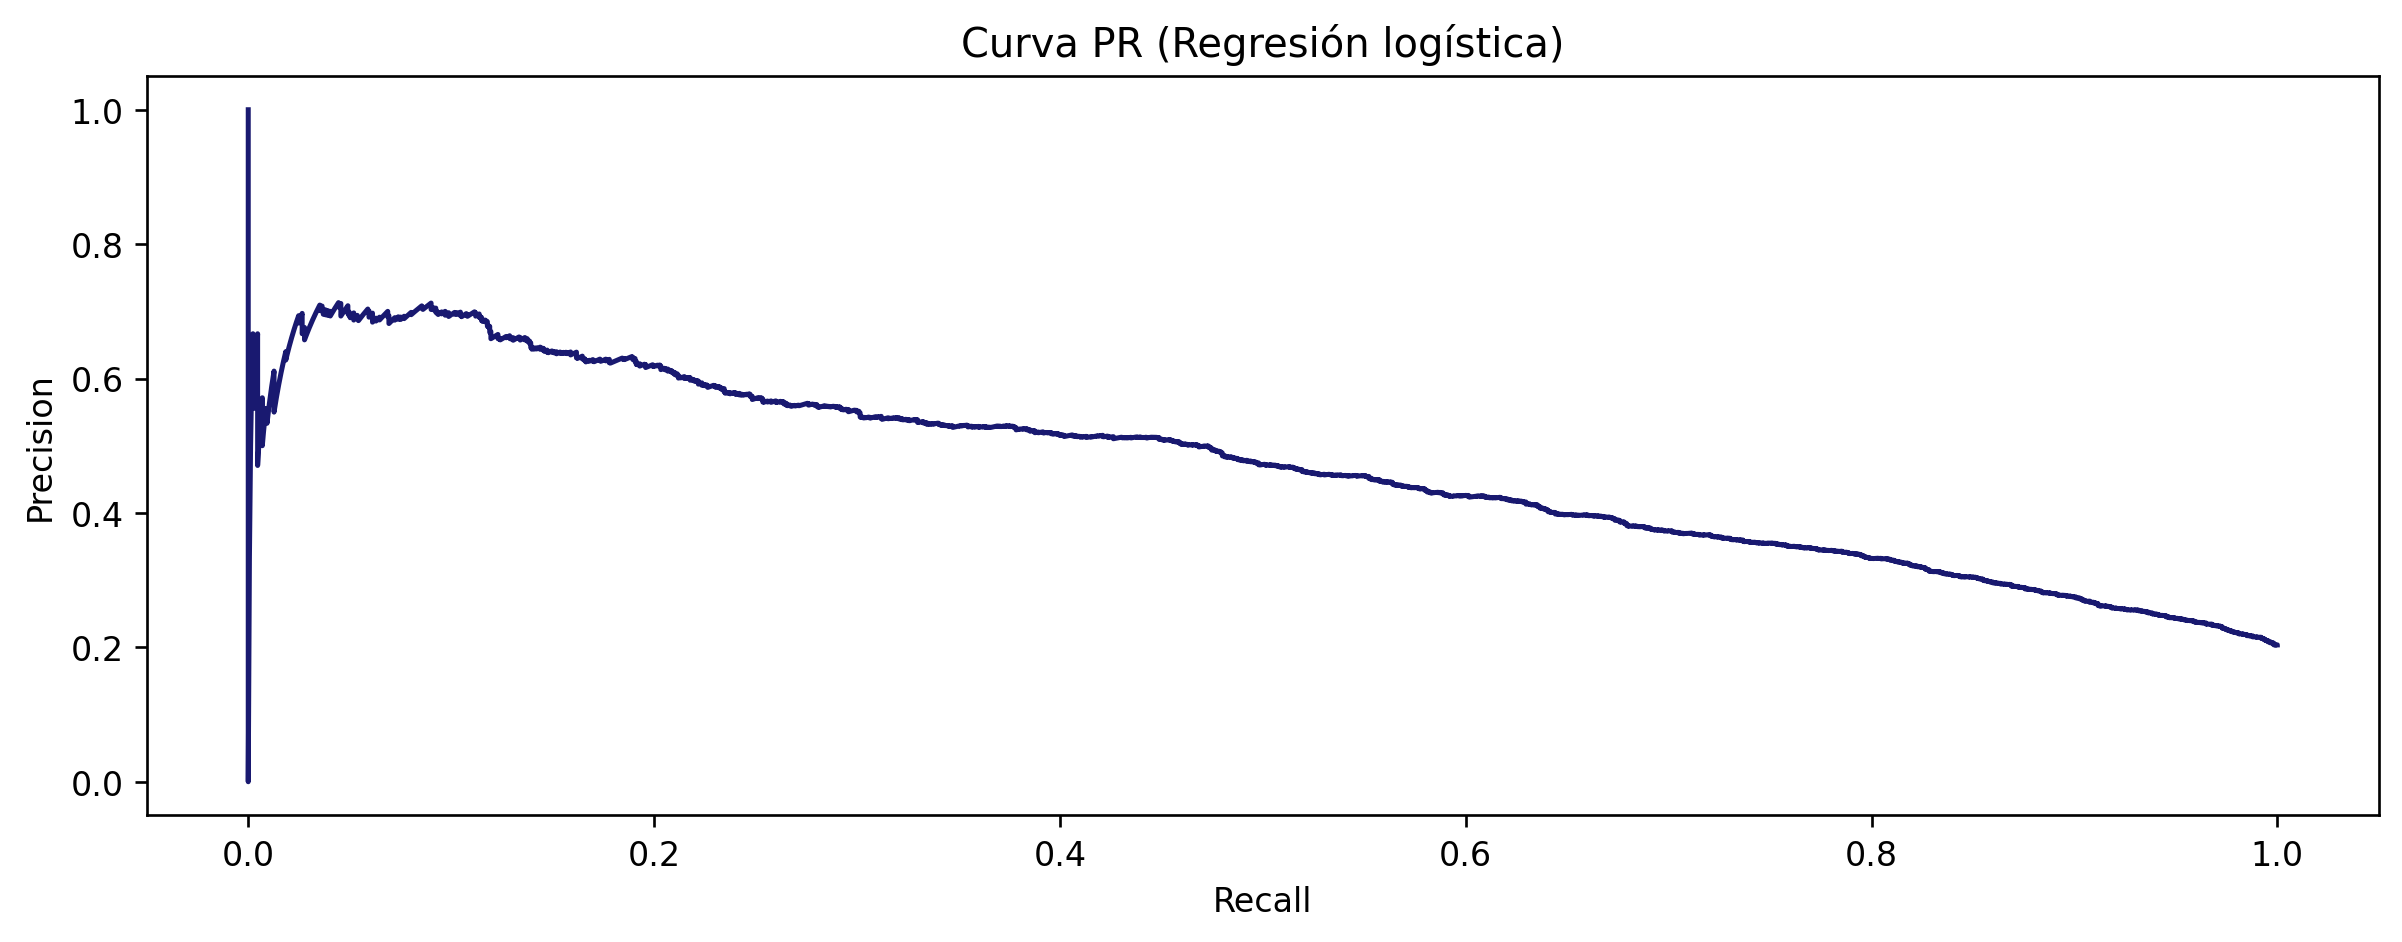

In [60]:
fig, axs = plt.subplots(dpi = 240, figsize = (12,4))
axs.set_title("Curva PR (Regresión logística)")
axs.plot(recall, precision, c = '#191970')
axs.set_xlabel("Recall")
axs.set_ylabel("Precision")
plt.show()

In [61]:
f2_score = fbeta_pr(precision, recall, 2)
index_max = np.argmax(f2_score)
print(f'f2-score: {f2_score[index_max]:.4f}, recall: {recall[index_max]:.4f}, precision: {precision[index_max]:.4f}')
print(f'New threshold: {thresholds[index_max]:.4f}')

f2-score: 0.6279, recall: 0.8094, precision: 0.3310
New threshold: 0.1531


              precision    recall  f1-score   support

           0       0.91      0.57      0.70      1194
           1       0.31      0.77      0.45       306

    accuracy                           0.61      1500
   macro avg       0.61      0.67      0.57      1500
weighted avg       0.79      0.61      0.65      1500

F2-score : 0.5966


<Figure size 2304x1728 with 0 Axes>

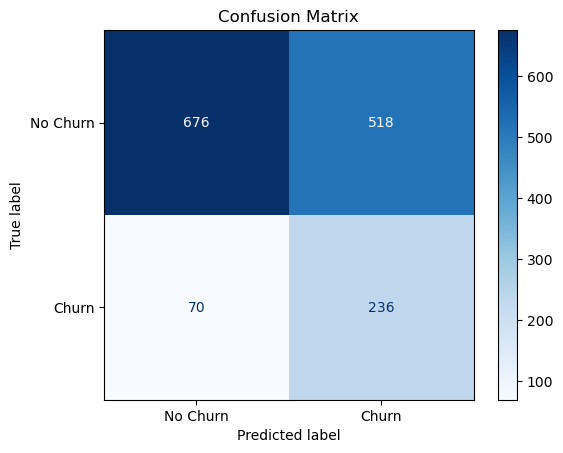

In [62]:
y_hat = (model.predict_proba(X_test)[:,1] >= thresholds[index_max]).astype(int)
f2 = report_metrics(y_test, y_hat)

In [63]:
model_resume = {'model_name': 'Regresión logística ALL',
                'recall': recall,
                'precision': precision,
                'threshold': thresholds[index_max],
                'f2-score': f2}

history_models.append(model_resume)

Ahora, se implementará una regresión logística para el conjunto de datos reducidos. 

In [64]:
model = LogisticRegression(penalty='elasticnet',
                                  solver='saga',
                                  C=0.5,
                                  l1_ratio = 0.85,
                                  random_state=SEED,
                                  max_iter=500)

skf = StratifiedKFold(n_splits = 5, shuffle=True,)
skf.get_n_splits(X_train_drop, y_train)
oof_pred = np.zeros((len(X_train_drop), 2))

for fold, (train_index, test_index) in enumerate(skf.split(X_train_drop, y_train)):
    model.fit(X_train_drop.iloc[train_index], y_train.iloc[train_index])
    oof_pred[test_index, :] = model.predict_proba(X_train_drop.iloc[test_index])

In [65]:
precision, recall, thresholds = precision_recall_curve(y_train, oof_pred[:,1])

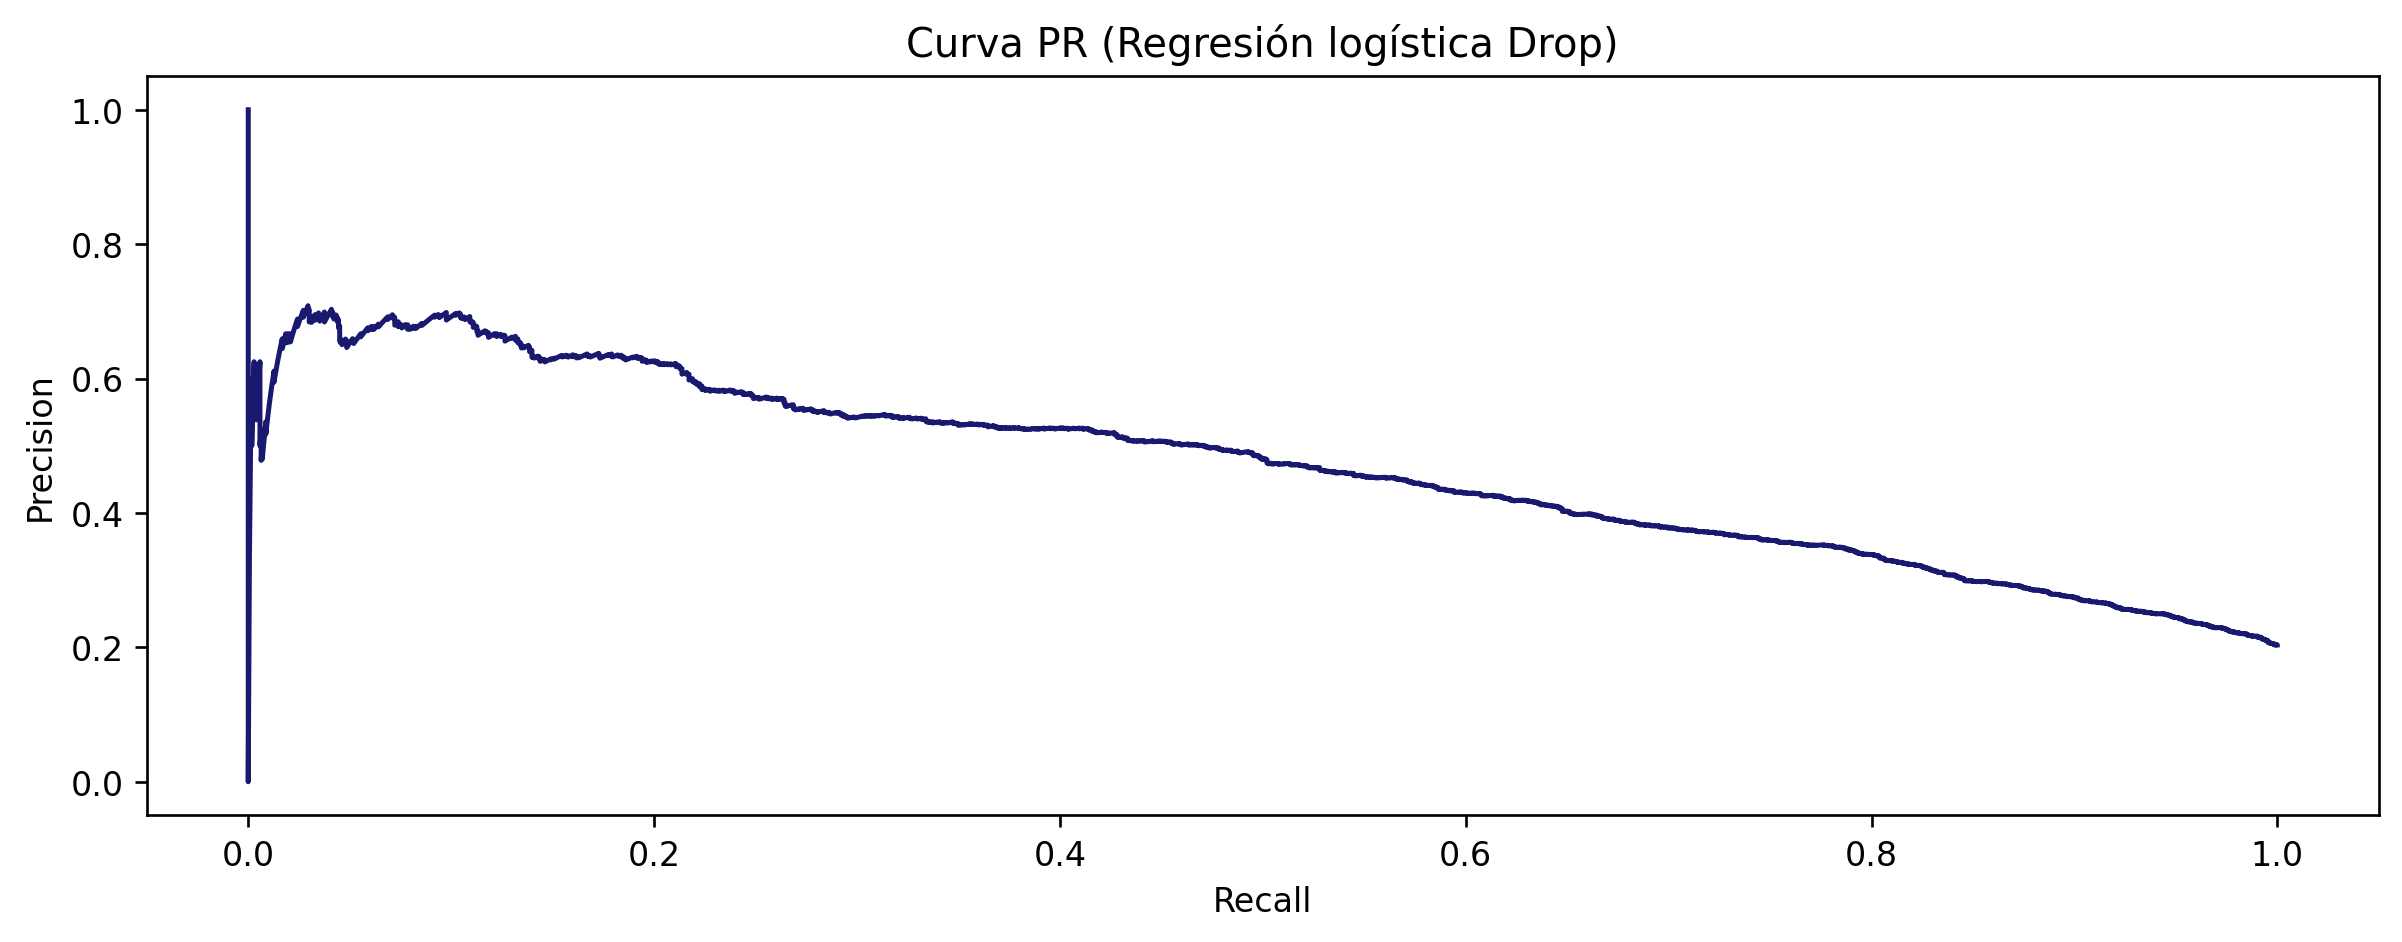

In [66]:
fig, axs = plt.subplots(dpi = 240, figsize = (12,4))
axs.set_title("Curva PR (Regresión logística Drop)")
axs.plot(recall, precision, c = '#191970')
axs.set_xlabel("Recall")
axs.set_ylabel("Precision")
plt.show()

In [67]:
f2_score = fbeta_pr(precision, recall, 2)
index_max = np.argmax(f2_score)
print(f'f2-score: {f2_score[index_max]:.4f}, recall: {recall[index_max]:.4f}, precision: {precision[index_max]:.4f}')
print(f'New threshold: {thresholds[index_max]:.4f}')

f2-score: 0.6288, recall: 0.8036, precision: 0.3362
New threshold: 0.1567


              precision    recall  f1-score   support

           0       0.91      0.59      0.72      1194
           1       0.33      0.77      0.46       306

    accuracy                           0.63      1500
   macro avg       0.62      0.68      0.59      1500
weighted avg       0.79      0.63      0.66      1500

F2-score : 0.6035


<Figure size 2304x1728 with 0 Axes>

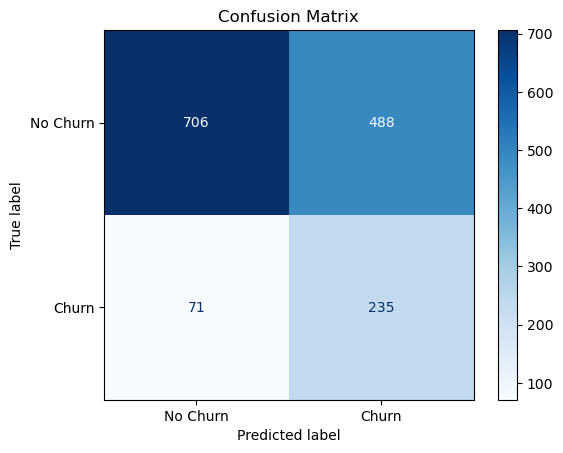

In [68]:
y_hat = (model.predict_proba(X_test_drop)[:,1] >= thresholds[index_max]).astype(int)
f2 = report_metrics(y_test, y_hat)

In [69]:
model_resume = {'model_name': 'Regresión logística DROP',
                'recall': recall,
                'precision': precision,
                'threshold': thresholds[index_max],
                'f2-score': f2}

history_models.append(model_resume)

### Arboles de decisión

In [70]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(criterion = 'gini',
                               splitter = 'best',
                               max_depth = 15,
                               max_leaf_nodes = 20,
                               min_samples_leaf = 10,
                               min_samples_split = 15,
                               class_weight = 'balanced',
                               random_state = SEED)

skf = StratifiedKFold(n_splits = 5, shuffle=True,)
skf.get_n_splits(X_train, y_train)
oof_pred = np.zeros((len(X_train), 2))

for fold, (train_index, test_index) in enumerate(skf.split(X_train, y_train)):
    model.fit(X_train.iloc[train_index], y_train.iloc[train_index])
    oof_pred[test_index, :] = model.predict_proba(X_train.iloc[test_index])

In [71]:
precision, recall, thresholds = precision_recall_curve(y_train, oof_pred[:,1])

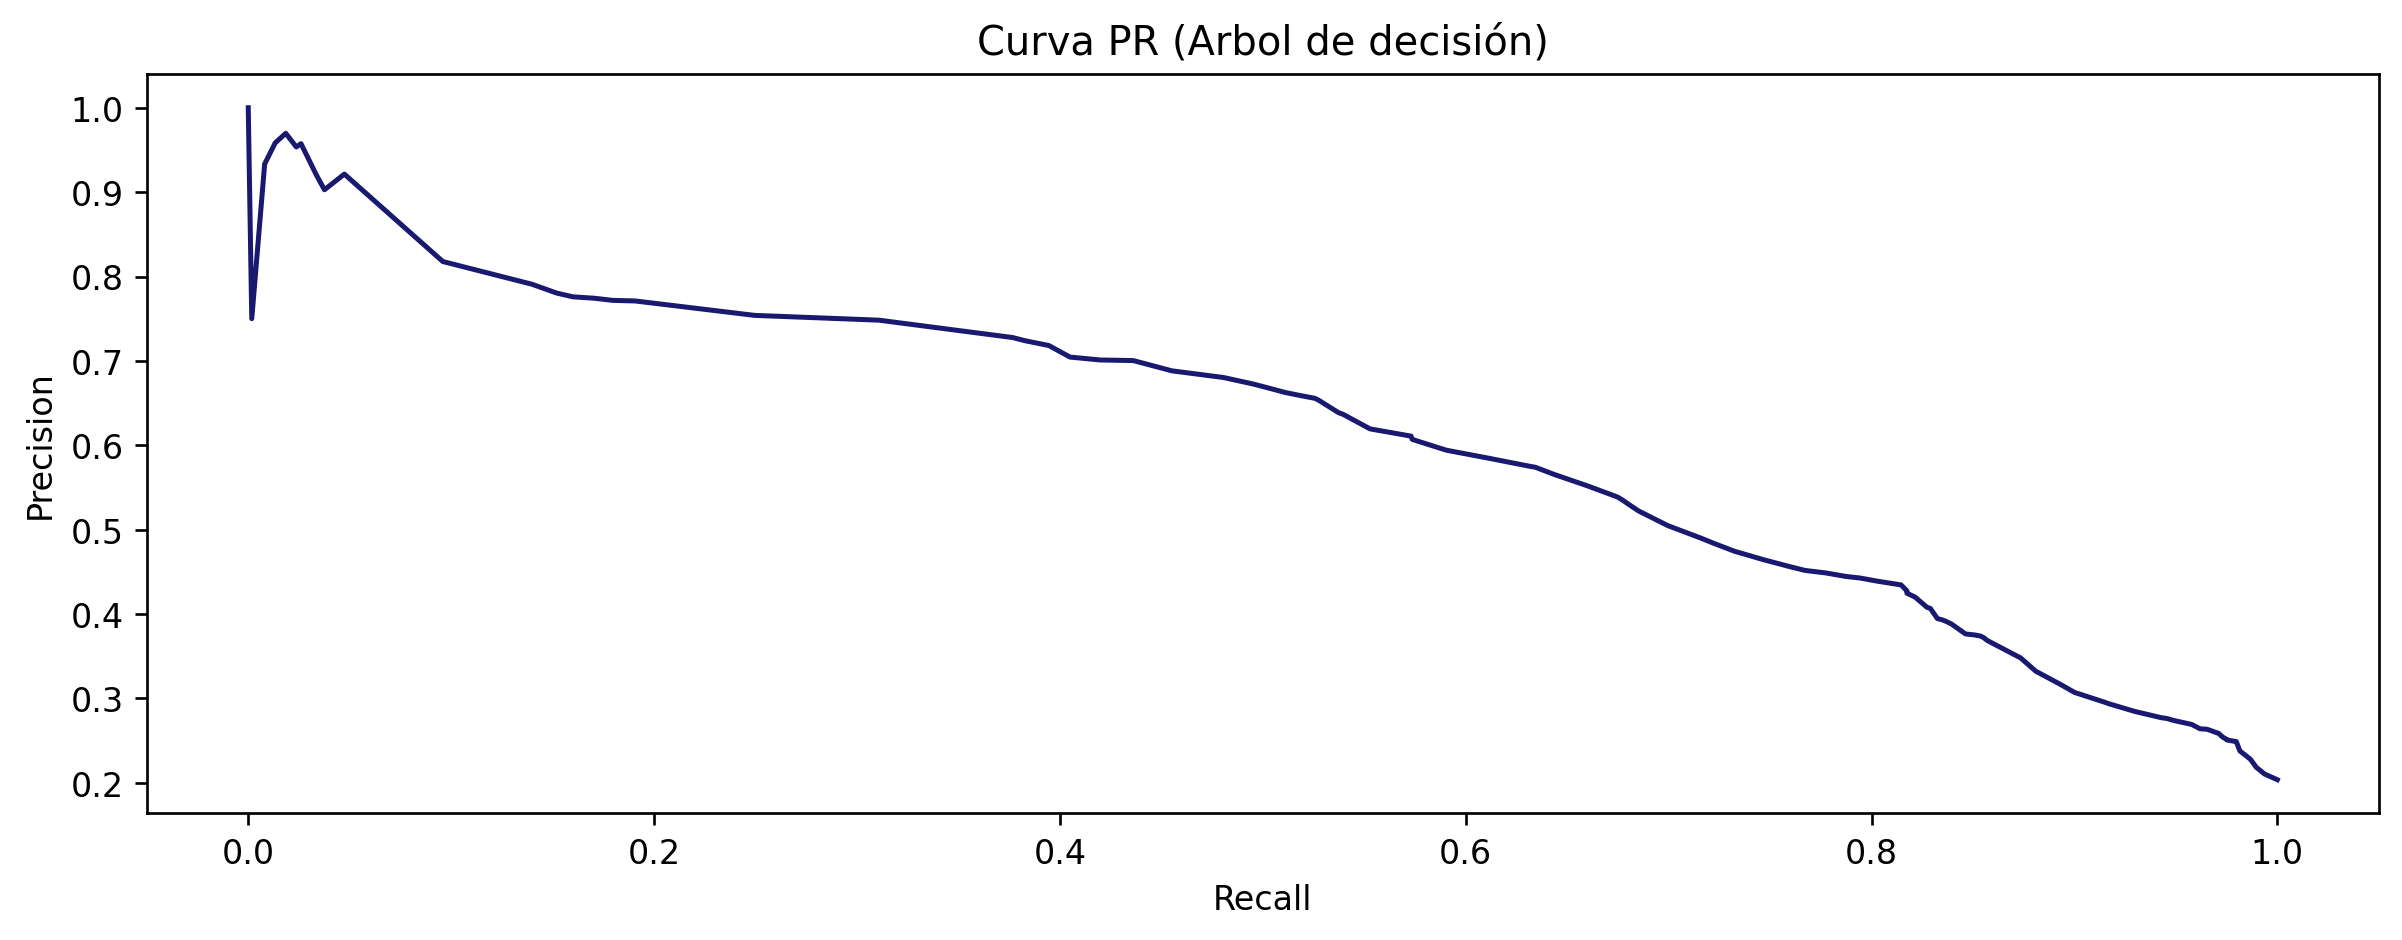

In [72]:
fig, axs = plt.subplots(dpi = 240, figsize = (12,4))
axs.set_title("Curva PR (Arbol de decisión)")
axs.plot(recall, precision, c = '#191970')
axs.set_xlabel("Recall")
axs.set_ylabel("Precision")
plt.show()

In [73]:
f2_score = fbeta_pr(precision, recall, 2)
index_max = np.argmax(f2_score)
print(f'f2-score: {f2_score[index_max]:.4f}, recall: {recall[index_max]:.4f}, precision: {precision[index_max]:.4f}')
print(f'New threshold: {thresholds[index_max]:.4f}')

f2-score: 0.6933, recall: 0.8146, precision: 0.4345
New threshold: 0.4290


              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1194
           1       0.42      0.75      0.54       306

    accuracy                           0.74      1500
   macro avg       0.67      0.74      0.68      1500
weighted avg       0.82      0.74      0.76      1500

F2-score : 0.6497


<Figure size 2304x1728 with 0 Axes>

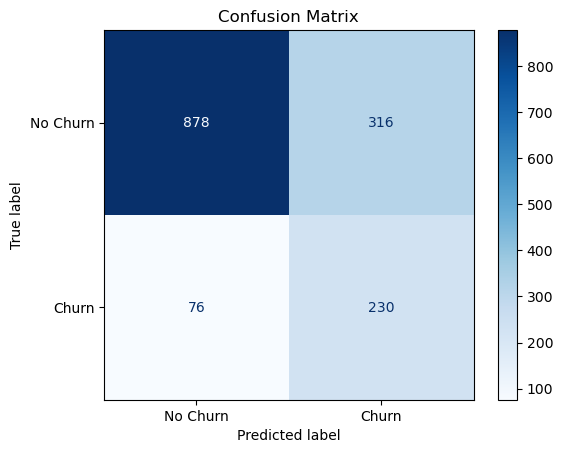

In [74]:
y_hat = (model.predict_proba(X_test)[:,1] >= thresholds[index_max]).astype(int)
f2 = report_metrics(y_test, y_hat)

In [75]:
model_resume = {'model_name': 'Arbol de decisión ALL',
                'recall': recall,
                'precision': precision,
                'threshold': thresholds[index_max],
                'f2-score': f2}

history_models.append(model_resume)

Decision Tree drop

In [76]:
model = DecisionTreeClassifier(criterion = 'gini',
                               splitter = 'best',
                               max_depth = 15,
                               max_leaf_nodes = 20,
                               min_samples_leaf = 10,
                               min_samples_split = 20,
                               class_weight = 'balanced',
                               random_state = SEED)

skf = StratifiedKFold(n_splits = 5, shuffle=True,)
skf.get_n_splits(X_train_drop, y_train)
oof_pred = np.zeros((len(X_train_drop), 2))

for fold, (train_index, test_index) in enumerate(skf.split(X_train_drop, y_train)):
    model.fit(X_train_drop.iloc[train_index], y_train.iloc[train_index])
    oof_pred[test_index, :] = model.predict_proba(X_train_drop.iloc[test_index])

In [77]:
precision, recall, thresholds = precision_recall_curve(y_train, oof_pred[:,1])

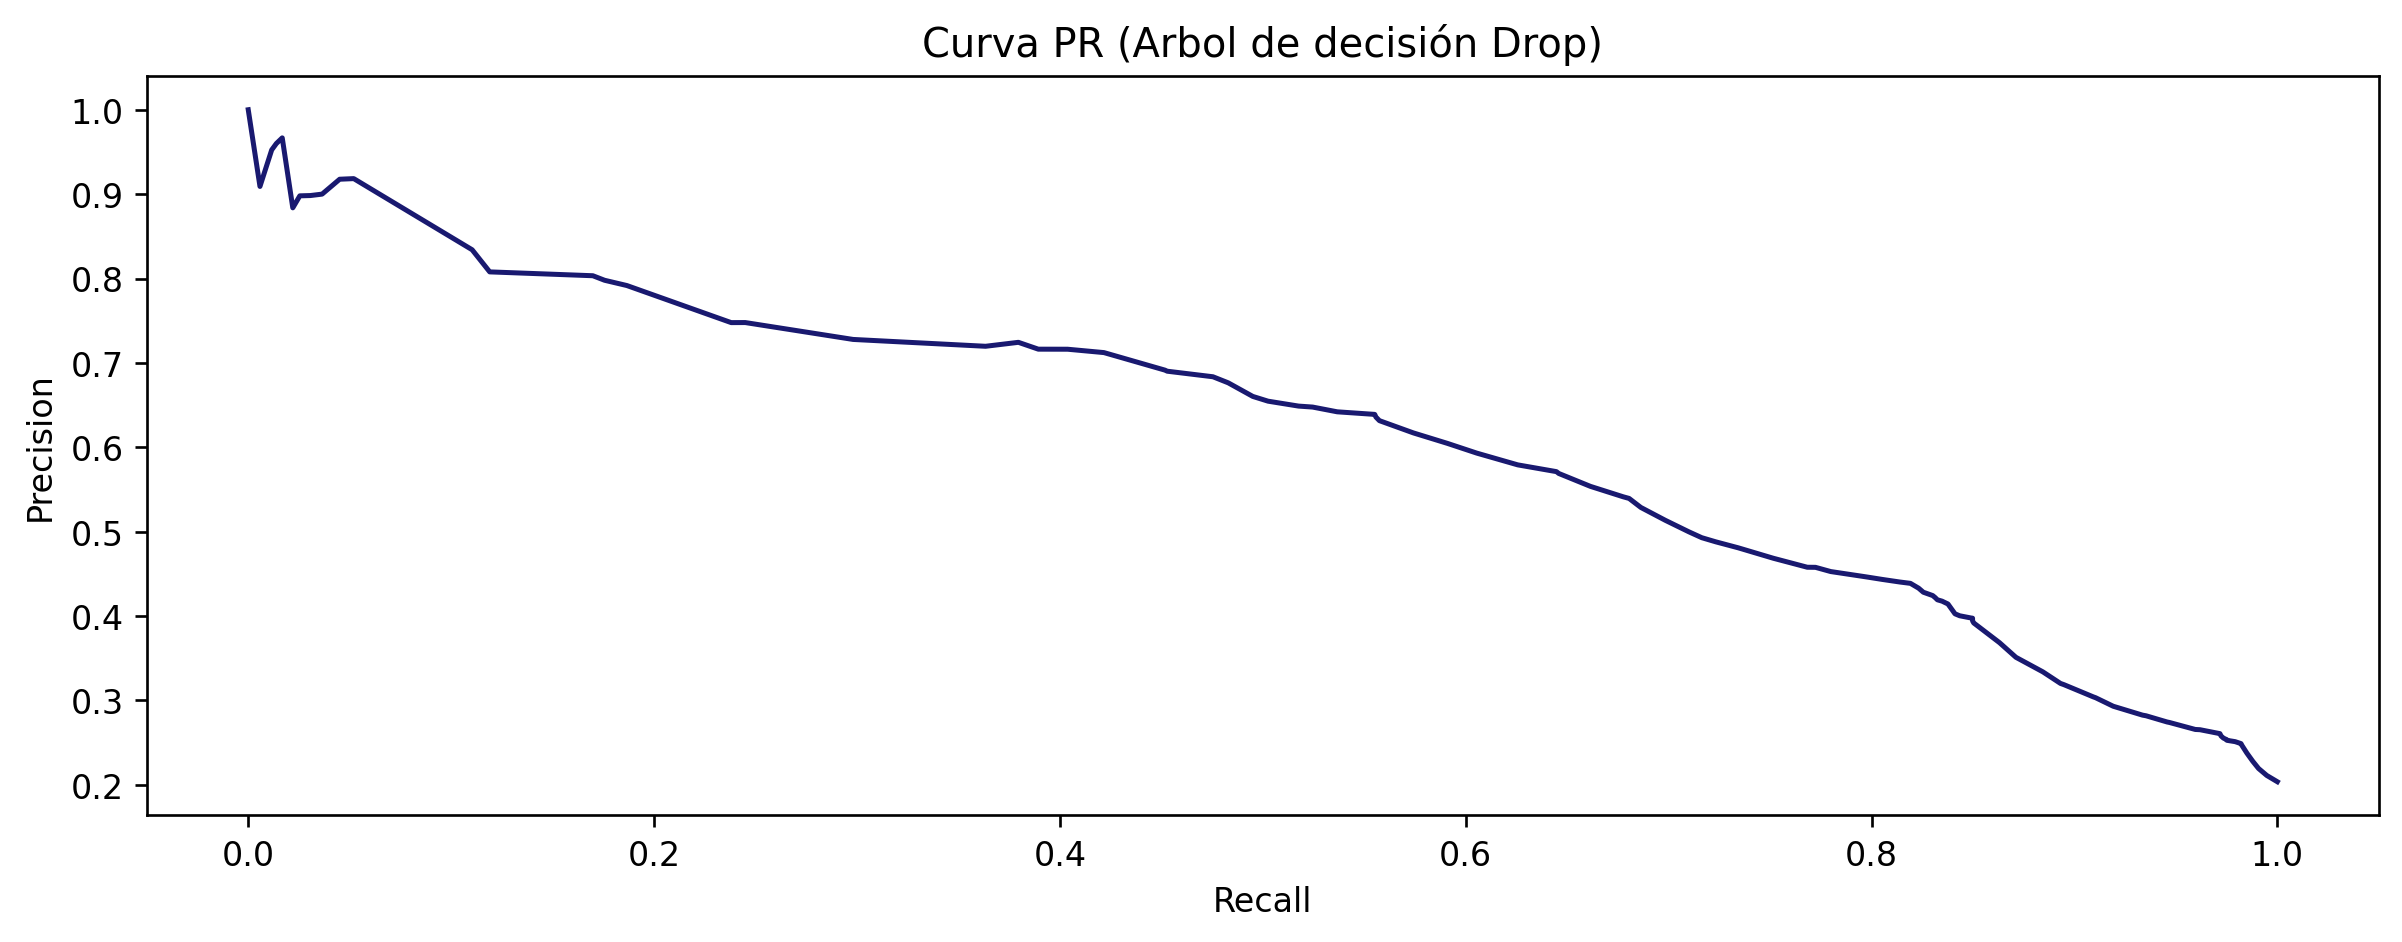

In [78]:
fig, axs = plt.subplots(dpi = 240, figsize = (12,4))
axs.set_title("Curva PR (Arbol de decisión Drop)")
axs.plot(recall, precision, c = '#191970')
axs.set_xlabel("Recall")
axs.set_ylabel("Precision")
plt.show()

In [79]:
f2_score = fbeta_pr(precision, recall, 2)
index_max = np.argmax(f2_score)
print(f'f2-score: {f2_score[index_max]:.4f}, recall: {recall[index_max]:.4f}, precision: {precision[index_max]:.4f}')
print(f'New threshold: {thresholds[index_max]:.4f}')

f2-score: 0.6981, recall: 0.8192, precision: 0.4387
New threshold: 0.4129


              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1194
           1       0.42      0.75      0.54       306

    accuracy                           0.74      1500
   macro avg       0.67      0.74      0.68      1500
weighted avg       0.82      0.74      0.76      1500

F2-score : 0.6474


<Figure size 2304x1728 with 0 Axes>

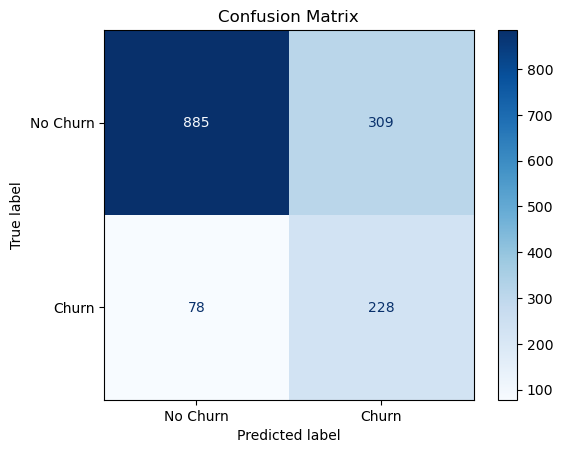

In [80]:
y_hat = (model.predict_proba(X_test_drop)[:,1] >= thresholds[index_max]).astype(int)
f2 = report_metrics(y_test, y_hat)

In [90]:
model_resume = {'model_name': 'Arbol de decisión DROP',
                'recall': recall,
                'precision': precision,
                'threshold': thresholds[index_max],
                'f2-score': f2}

history_models.append(model_resume)

f2-score Regresión logística ALL: 0.5966
f2-score Regresión logística DROP: 0.6035
f2-score Arbol de decisión ALL: 0.6497
f2-score Arbol de decisión DROP: 0.6474


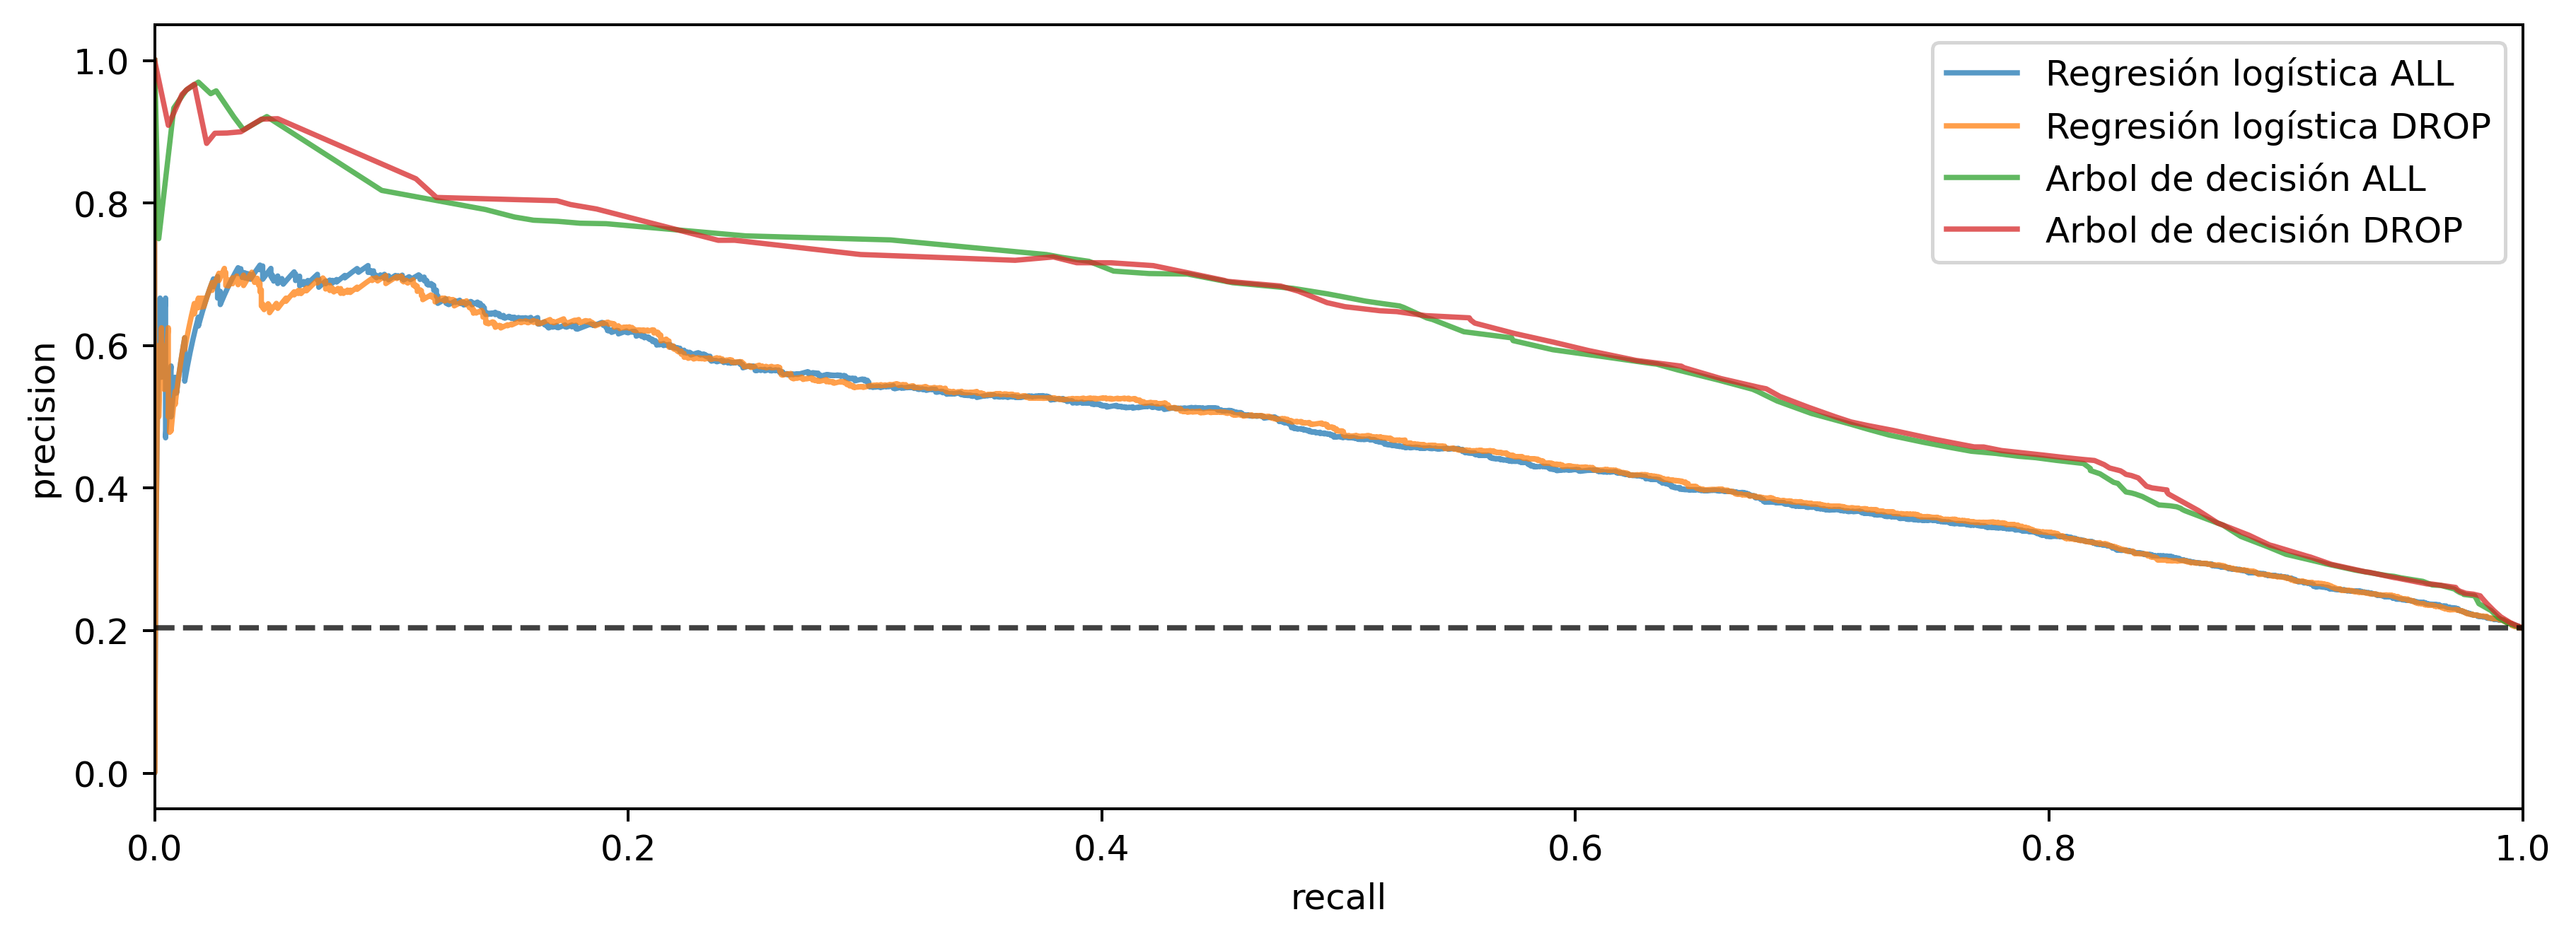

In [106]:
plt.figure(dpi = 360, figsize = (12,4))
prevalencia = np.mean(y_train == 1)
for i, model_resume in enumerate(history_models):
    print(f'f2-score {model_resume['model_name']}: {model_resume['f2-score']:.4f}')
    plt.plot(model_resume['recall'], model_resume['precision'], color=f"C{i}", label = model_resume['model_name'], alpha = 0.75)
plt.legend()
plt.axhline(prevalencia, color = 'black', linestyle = '--', alpha = 0.75)
plt.xlim([0,1])
plt.xlabel('recall')
plt.ylabel('precision')
plt.show()

In [82]:
# Definiendo métricas
scoring = {'accuracy': make_scorer(accuracy_score),
           'recall': make_scorer(recall_score),
           'precision': make_scorer(precision_score),
           'f2_score': make_scorer(fbeta_score, beta=2)}

# Compilando modelo
model = RandomizedSearchCV(logistic_reg,
                           param_distributions = param_distributions,
                           scoring=scoring,
                           refit='f2_score',
                           n_iter=50,
                           cv=5,
                           random_state=SEED)

NameError: name 'logistic_reg' is not defined